<div class="alert alert-block">
<b>Step 2:</b> Models</div>

_Imports_

In [1]:
import pandas as pd
import geopandas as gpd # (.shp)
import matplotlib.pyplot as plt
import rasterio # (.tif)
from rasterio.mask import mask
from tqdm import tqdm
import os
import glob
import seaborn as sns
import numpy as np
#import pyodbc
from rasterstats import zonal_stats
import pickle
from shapely.geometry import Point 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter 
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix





_Loading Datasets_

In [2]:
"""
save_path = "data/processed/df_2km.pkl"

with open(save_path, "rb") as f:
       df_2km = pickle.load(f)        """
        

save_path = "data/processed/df_encoded.pkl"

with open(save_path, "rb") as f:
       df_encoded = pickle.load(f)    

# Chemins vers les fichiers pickle
X_train_path = "data/processed/X_train.pkl"
y_train_path = "data/processed/y_train.pkl"
X_test_path  = "data/processed/X_test.pkl"
y_test_path  = "data/processed/y_test.pkl"

# Chargement des fichiers pickle
with open(X_train_path, "rb") as f:
    X_train = pickle.load(f)

with open(y_train_path, "rb") as f:
    y_train = pickle.load(f)

with open(X_test_path, "rb") as f:
    X_test = pickle.load(f)

with open(y_test_path, "rb") as f:
    y_test = pickle.load(f)


X_train_res_smote_path = "data/processed/X_train_res_smote.pkl"
y_train_res_smote_path = "data/processed/y_train_res_smote.pkl"
X_train_res_rus_path = "data/processed/X_train_res_rus.pkl"
y_train_res_rus_path = "data/processed/y_train_res_rus.pkl"

with open(X_train_res_smote_path, "rb") as f:
    X_train_res_smote = pickle.load(f)

with open(y_train_res_smote_path, "rb") as f:
    y_train_res_smote = pickle.load(f)

with open(X_train_res_rus_path, "rb") as f:
    X_train_res_rus = pickle.load(f)

with open(y_train_res_rus_path, "rb") as f:
    y_train_res_rus = pickle.load(f)
 
""" with open("data/processed/y_pred_knn_smote.pkl", "rb") as f:
    y_pred_knn_smote = pickle.load(f) 

with open("data/processed/y_pred_knn_rus.pkl", "rb") as f:
    y_pred_knn_rus = pickle.load(f)

with open("data/processed/y_pred_dt_smote.pkl", "rb") as f:
    y_pred_dt_smote = pickle.load(f)

with open("data/processed/y_pred_dt_rus.pkl", "rb") as f:
    y_pred_dt_rus = pickle.load(f)

with open("data/processed/y_pred_rf_original.pkl", "rb") as f:
    y_pred_rf_orig = pickle.load(f)

with open("data/processed/y_pred_rf_smote.pkl", "rb") as f:
    y_pred_rf_smote = pickle.load(f)

with open("data/processed/y_pred_rf_balanced.pkl", "rb") as f:
    y_pred_rf_balanced = pickle.load(f)

y_pred_dbscan_path = "data/processed/y_pred_dbscan.pkl"  

with open(y_pred_dbscan_path, "rb") as f:
    y_pred_dbscan = pickle.load(f) """

""" cleaned_path = "data/processed/df_cleaned.pkl"  

with open(cleaned_path, "rb") as f:
    df_cleaned = pickle.load(f)    
 """
all_path = "data/processed/df_all.pkl"

with open(all_path, "rb") as f:
    df_all = pickle.load(f) 


""" # encoded = cleaned (we changed the name because the original code was written with df_encoded so we did it for convenience)
df_encoded = df_cleaned.copy()
 """



' # encoded = cleaned (we changed the name because the original code was written with df_encoded so we did it for convenience)\ndf_encoded = df_cleaned.copy()\n '

In [3]:
df_encoded.columns


Index(['prec_winter', 'prec_spring', 'prec_summer', 'prec_fall', 'tmax_winter',
       'tmax_spring', 'tmax_summer', 'tmax_fall', 'tmin_winter', 'tmin_spring',
       'tmin_summer', 'tmin_fall', 'elevation', 'COARSE', 'SAND', 'CLAY',
       'ORG_CARBON', 'PH_WATER', 'CN_RATIO', 'CEC_CLAY', 'CEC_EFF', 'BSAT',
       'ALUM_SAT', 'TCARBON_EQ', 'GYPSUM', 'TEXTURE_SOTER_-',
       'TEXTURE_SOTER_C', 'TEXTURE_SOTER_F', 'TEXTURE_SOTER_M',
       'ELEC_COND_0.0', 'ELEC_COND_1.0', 'ELEC_COND_14.0', 'ELEC_COND_16.0',
       'ELEC_COND_2.0', 'ELEC_COND_32.0', 'LCCCode_0003 / 0004',
       'LCCCode_0004 // 0003', 'LCCCode_0010', 'LCCCode_0011',
       'LCCCode_11490 // 11494', 'LCCCode_11498', 'LCCCode_20049 // 20058',
       'LCCCode_20058', 'LCCCode_21446 // 21450-121340 / 21454',
       'LCCCode_21450', 'LCCCode_21454 // 21446 // 21450',
       'LCCCode_21496-121340 // 21497-129401', 'LCCCode_21497-121340',
       'LCCCode_21497-15045', 'LCCCode_21499-121340', 'LCCCode_21518',
       'LCCCode_6

In [46]:
# Convert boolean columns to integers
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

# Verify
print(df_encoded[bool_cols].head())
print(df_encoded.dtypes)


Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]
prec_winter                              float32
prec_spring                              float32
prec_summer                              float32
prec_fall                                float32
tmax_winter                              float32
tmax_spring                              float32
tmax_summer                              float32
tmax_fall                                float32
tmin_winter                              float32
tmin_spring                              float32
tmin_summer                              float32
tmin_fall                                float32
elevation                                  int16
COARSE                                   float64
SAND                                     float64
CLAY                                     float64
ORG_CARBON                               float64
PH_WATER                                 float64
CN_RATIO                                 float64
CEC_CLAY          

In [5]:
# Make sure all columns are displayed
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)  # widen display
pd.set_option('display.max_rows', None)  # optional, for rows

# Now print the dtypes
print(df_encoded.dtypes)



lat                                      float64
lon                                      float64
fire                                       int64
prec_winter                              float32
prec_spring                              float32
prec_summer                              float32
prec_fall                                float32
tmax_winter                              float32
tmax_spring                              float32
tmax_summer                              float32
tmax_fall                                float32
tmin_winter                              float32
tmin_spring                              float32
tmin_summer                              float32
tmin_fall                                float32
elevation                                  int16
COARSE                                   float64
SAND                                     float64
CLAY                                     float64
ORG_CARBON                               float64
PH_WATER            

In [43]:
# Fill NaNs with 0 (or any suitable value)
df_encoded = df_encoded.fillna(0)


## Split Train/Test

In [4]:
df_all.columns

Index(['lat', 'lon', 'fire', 'prec_winter', 'prec_spring', 'prec_summer',
       'prec_fall', 'tmax_winter', 'tmax_spring', 'tmax_summer', 'tmax_fall',
       'tmin_winter', 'tmin_spring', 'tmin_summer', 'tmin_fall', 'elevation',
       'COARSE', 'SAND', 'CLAY', 'ORG_CARBON', 'PH_WATER', 'CN_RATIO',
       'CEC_CLAY', 'CEC_EFF', 'BSAT', 'ALUM_SAT', 'TCARBON_EQ', 'GYPSUM',
       'TEXTURE_SOTER_-', 'TEXTURE_SOTER_C', 'TEXTURE_SOTER_F',
       'TEXTURE_SOTER_M', 'ELEC_COND_0.0', 'ELEC_COND_1.0', 'ELEC_COND_14.0',
       'ELEC_COND_16.0', 'ELEC_COND_2.0', 'ELEC_COND_32.0',
       'LCCCode_0003 / 0004', 'LCCCode_0004 // 0003', 'LCCCode_0010',
       'LCCCode_0011', 'LCCCode_11490 // 11494', 'LCCCode_11498',
       'LCCCode_20049 // 20058', 'LCCCode_20058',
       'LCCCode_21446 // 21450-121340 / 21454', 'LCCCode_21450',
       'LCCCode_21454 // 21446 // 21450',
       'LCCCode_21496-121340 // 21497-129401', 'LCCCode_21497-121340',
       'LCCCode_21497-15045', 'LCCCode_21499-121340', 'LCCC

In [7]:
# --- Step 1 : garder une copie complète ---
df_all = df_encoded.copy()  # df_all contient tout

# --- Step 2 : retirer lat, lon et fire pour df_encoded ---
df_encoded = df_encoded.drop(columns=['lat', 'lon', 'fire'])

In [5]:
# Separate features and target
X = df_encoded.copy()           # X = toutes les features sauf lon, lat et fire
y = df_all['fire'].copy()       # y = target fire depuis df_all

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
df_all.to_pickle("data/processed/df_all.pkl")
df_encoded.to_pickle("data/processed/df_encoded.pkl")


## Identify numeric features for scaling

In [6]:
numeric_cols = X.select_dtypes(include=['float64', 'float32', 'int64']).columns
len(numeric_cols)

57

In [7]:

scaler = StandardScaler()

# Fit only on training data
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Apply the same transformation to test data
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

## ON SAUVEGARDE

In [8]:

output_dir = "data/processed/"
os.makedirs(output_dir, exist_ok=True)

# Sauvegarder X_train
X_train_path = os.path.join(output_dir, "X_train.pkl")
X_train.to_pickle(X_train_path)

# Sauvegarder y_train
y_train_path = os.path.join(output_dir, "y_train.pkl")
y_train.to_pickle(y_train_path)

# Sauvegarder X_test
X_test_path = os.path.join(output_dir, "X_test.pkl")
X_test.to_pickle(X_test_path)

# Sauvegarder y_test
y_test_path = os.path.join(output_dir, "y_test.pkl")
y_test.to_pickle(y_test_path)

print(f"X_train saved at: {X_train_path}")
print(f"y_train saved at: {y_train_path}")
print(f"X_test saved at: {X_test_path}")
print(f"y_test saved at: {y_test_path}")


X_train saved at: data/processed/X_train.pkl
y_train saved at: data/processed/y_train.pkl
X_test saved at: data/processed/X_test.pkl
y_test saved at: data/processed/y_test.pkl


## Handling imbalance

### Method 1: SMOTE oversampling

Synthetic Minority Over-sampling Technique.

Generates new synthetic “fire” points from existing ones.

Works well with k-NN because it creates realistic neighbors.

In [9]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [10]:
# Make sure X_train_res and y_train_res are numeric arrays
X_train_res = X_train_res.astype(float).to_numpy()
y_train_res = y_train_res.astype(int).to_numpy()


### Method 2: Random undersampling

Reduce the number of majority class (“non-fire”) points randomly.

Keeps the dataset balanced, but may discard some info.

In [11]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_train_res2, y_train_res2 = rus.fit_resample(X_train, y_train)

In [12]:
# Make sure X_train_res and y_train_res are numeric arrays
X_train_res2 = X_train_res2.astype(float).to_numpy()
y_train_res2 = y_train_res2.astype(int).to_numpy()


``we're keeping the test set imbalanced to reflect real world distribution``

## ON SAUVEGARDE 2

In [13]:
save_dict = {
    "X_train_res_smote": X_train_res,
    "y_train_res_smote": y_train_res,
    "X_train_res_rus": X_train_res2,
    "y_train_res_rus": y_train_res2
}

for name, dataset in save_dict.items():
    path = f"data/processed/{name}.pkl"
    with open(path, "wb") as f:
        pickle.dump(dataset, f)
    print(f"{name} saved at {path}")

X_train_res_smote saved at data/processed/X_train_res_smote.pkl
y_train_res_smote saved at data/processed/y_train_res_smote.pkl
X_train_res_rus saved at data/processed/X_train_res_rus.pkl
y_train_res_rus saved at data/processed/y_train_res_rus.pkl


## KNN from scratch

In [90]:
class KNN:
    def __init__(self, k=5):
        self.k = k
        
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        
    def predict(self, X):
        predictions = []
        for x in X:
            # Compute Euclidean distances to all training points
            distances = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
            
            # Find the indices of k nearest neighbors
            k_indices = np.argsort(distances)[:self.k]
            k_labels = self.y_train[k_indices]
            
            # Majority vote
            most_common = Counter(k_labels).most_common(1)[0][0]
            predictions.append(most_common)
        return np.array(predictions)


In [91]:
# =========================
# KD-Tree Node
# =========================
class KDNode:
    def __init__(self, point=None, label=None, left=None, right=None, axis=0):
        self.point = point      # feature vector
        self.label = label      # target
        self.left = left        # left subtree
        self.right = right      # right subtree
        self.axis = axis        # splitting axis

# =========================
# KD-Tree Build
# =========================
def build_kdtree(X, y, depth=0):
    if len(X) == 0:
        return None
    k = X.shape[1]  # number of features
    axis = depth % k
    sorted_idx = X[:, axis].argsort()
    X = X[sorted_idx]
    y = y[sorted_idx]
    median_idx = len(X) // 2
    return KDNode(
        point=X[median_idx],
        label=y[median_idx],
        left=build_kdtree(X[:median_idx], y[:median_idx], depth+1),
        right=build_kdtree(X[median_idx+1:], y[median_idx+1:], depth+1),
        axis=axis
    )

# =========================
# KNN Query with KD-Tree
# =========================
def knn_query(node, x, k, heap):
    if node is None:
        return

    # Compute distance to current node
    dist = np.linalg.norm(x - node.point)
    
    # Maintain max-heap of k closest points
    if len(heap) < k:
        heap.append((dist, node.label))
        heap.sort(reverse=True)  # max-heap by distance
    elif dist < heap[0][0]:
        heap[0] = (dist, node.label)
        heap.sort(reverse=True)

    # Decide which subtree to visit first
    axis = node.axis
    diff = x[axis] - node.point[axis]
    
    first = node.left if diff < 0 else node.right
    second = node.right if diff < 0 else node.left
    
    knn_query(first, x, k, heap)
    
    # Check if we need to explore the other side
    if len(heap) < k or abs(diff) < heap[0][0]:
        knn_query(second, x, k, heap)

# =========================
# KD-Tree KNN Classifier
# =========================
class KDTreeKNN:
    def __init__(self, k=5):
        self.k = k
        self.tree = None
    
    def fit(self, X, y):
        self.tree = build_kdtree(np.array(X), np.array(y))
    
    def predict(self, X):
        preds = []
        for x in X:
            heap = []
            knn_query(self.tree, np.array(x), self.k, heap)
            labels = [label for _, label in heap]
            most_common = Counter(labels).most_common(1)[0][0]
            preds.append(most_common)
        return np.array(preds)


In [92]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    'n_neighbors': [3, 5],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}


In [93]:
knn = KNeighborsClassifier(algorithm='kd_tree') 

### Grid search with cross-validation

In [94]:
n_samples = 10000 
indices = np.random.choice(len(X_train_res), size=n_samples, replace=False)

X_sample = X_train_res[indices]
y_sample = y_train_res[indices]
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_sample, y_sample)


GridSearchCV(cv=5, estimator=KNeighborsClassifier(algorithm='kd_tree'),
             n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5],
                         'weights': ['uniform', 'distance']},
             scoring='f1')

In [95]:
import pandas as pd

results = pd.DataFrame(grid_search.cv_results_)


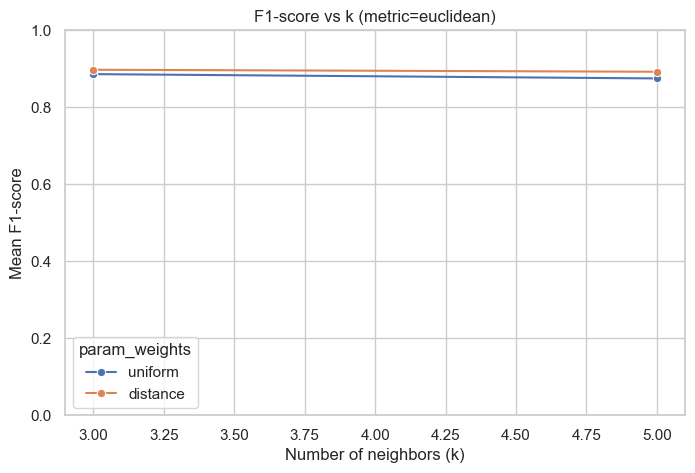

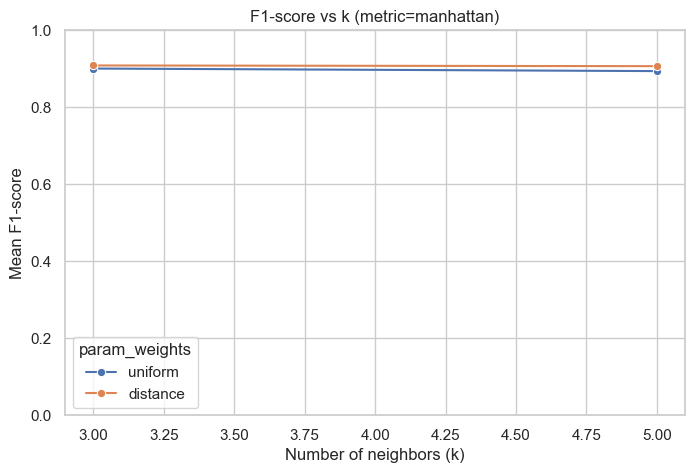

In [96]:
import seaborn as sns

sns.set(style="whitegrid")

# Filter for one metric at a time if needed
for metric in results['param_metric'].unique():
    df_metric = results[results['param_metric'] == metric]
    plt.figure(figsize=(8,5))
    sns.lineplot(data=df_metric, x='param_n_neighbors', y='mean_test_score', hue='param_weights', marker='o')
    plt.title(f'F1-score vs k (metric={metric})')
    plt.xlabel('Number of neighbors (k)')
    plt.ylabel('Mean F1-score')
    plt.ylim(0,1)
    plt.show()

In [97]:
print("Best parameters:", grid_search.best_params_)
print("Best F1-score:", grid_search.best_score_)


Best parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best F1-score: 0.9085364562190605


In [98]:
best_knn = grid_search.best_estimator_

# Train on the full (resampled/balanced) training set
best_knn.fit(X_train_res, y_train_res)

# Predict on the test set
y_pred = best_knn.predict(X_test)

c:\Users\HOME\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


In [99]:
# Evaluate
from sklearn.metrics import accuracy_score, f1_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9759301566579635
F1 Score: 0.9433827763002769
              precision    recall  f1-score   support

           0       0.99      0.98      0.98     67994
           1       0.92      0.97      0.94     17798

    accuracy                           0.98     85792
   macro avg       0.96      0.97      0.96     85792
weighted avg       0.98      0.98      0.98     85792



In [100]:
# Sauvegarde des prédictions KNN SMOTE
knn_smote_pred_path = "data/processed/y_pred_knn_smote.pkl"
with open(knn_smote_pred_path, "wb") as f:
    pickle.dump(y_pred, f)
print(f"y_pred KNN SMOTE saved at {knn_smote_pred_path}")


y_pred KNN SMOTE saved at data/processed/y_pred_knn_smote.pkl


## knn for methode 2: random undersampling

### Grid search with cross-validation

In [101]:
len(X_train_res2)


142388

In [102]:
n_samples = 10000 
indices = np.random.choice(len(X_train_res2), size=n_samples, replace=False)

X_sample2 = X_train_res2[indices]
y_sample2 = y_train_res2[indices]
grid_search2 = GridSearchCV(knn, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search2.fit(X_sample2, y_sample2)



GridSearchCV(cv=5, estimator=KNeighborsClassifier(algorithm='kd_tree'),
             n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5],
                         'weights': ['uniform', 'distance']},
             scoring='f1')

In [103]:
import pandas as pd

results2 = pd.DataFrame(grid_search2.cv_results_)


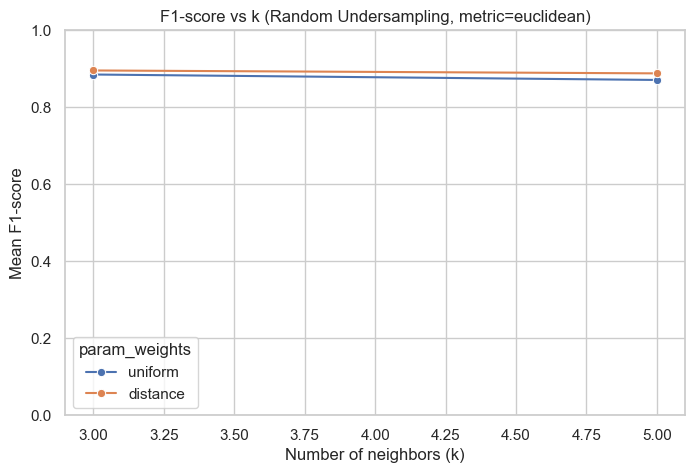

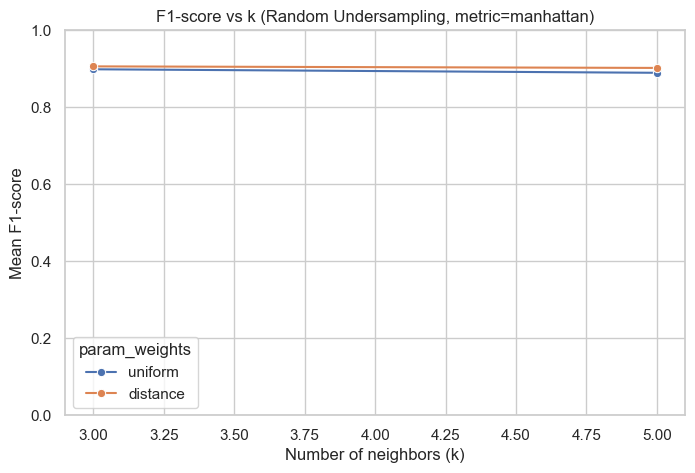

In [104]:
sns.set(style="whitegrid")

# Affichage des courbes F1-score vs k pour chaque métrique
for metric in results2['param_metric'].unique():
    df_metric = results2[results2['param_metric'] == metric]
    plt.figure(figsize=(8,5))
    sns.lineplot(data=df_metric, x='param_n_neighbors', y='mean_test_score', 
                 hue='param_weights', marker='o')
    plt.title(f'F1-score vs k (Random Undersampling, metric={metric})')
    plt.xlabel('Number of neighbors (k)')
    plt.ylabel('Mean F1-score')
    plt.ylim(0,1)
    plt.show()

In [105]:
# Meilleurs paramètres et meilleur score
print("Best parameters (RUS):", grid_search2.best_params_)
print("Best F1-score (RUS):", grid_search2.best_score_)

Best parameters (RUS): {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best F1-score (RUS): 0.906161504690685


In [106]:
# Meilleur modèle KNN pour Random Undersampling
best_knn_rus = grid_search2.best_estimator_

# Entraînement sur l'ensemble complet sous-échantillonné
best_knn_rus.fit(X_train_res2, y_train_res2)

# Prédictions sur le test set
y_pred_rus = best_knn_rus.predict(X_test)

c:\Users\HOME\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


In [107]:
# Évaluation
from sklearn.metrics import accuracy_score, f1_score, classification_report
print("Accuracy (RUS):", accuracy_score(y_test, y_pred_rus))
print("F1 Score (RUS):", f1_score(y_test, y_pred_rus))
print(classification_report(y_test, y_pred_rus))

Accuracy (RUS): 0.957222118612458
F1 Score (RUS): 0.9042025580788305
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     67994
           1       0.84      0.97      0.90     17798

    accuracy                           0.96     85792
   macro avg       0.92      0.96      0.94     85792
weighted avg       0.96      0.96      0.96     85792



In [108]:
# Sauvegarde des prédictions KNN RUS
knn_rus_pred_path = "data/processed/y_pred_knn_rus.pkl"
with open(knn_rus_pred_path, "wb") as f:
    pickle.dump(y_pred_rus, f)
print(f"y_pred KNN RUS saved at {knn_rus_pred_path}")


y_pred KNN RUS saved at data/processed/y_pred_knn_rus.pkl


## Comparaison des deux methodes avec knn

Comparaison des performances KNN :
                 Method  Accuracy  F1 Score  Precision    Recall
0                 SMOTE  0.975930  0.943383   0.921232  0.966625
1  Random Undersampling  0.957222  0.904203   0.844384  0.973143


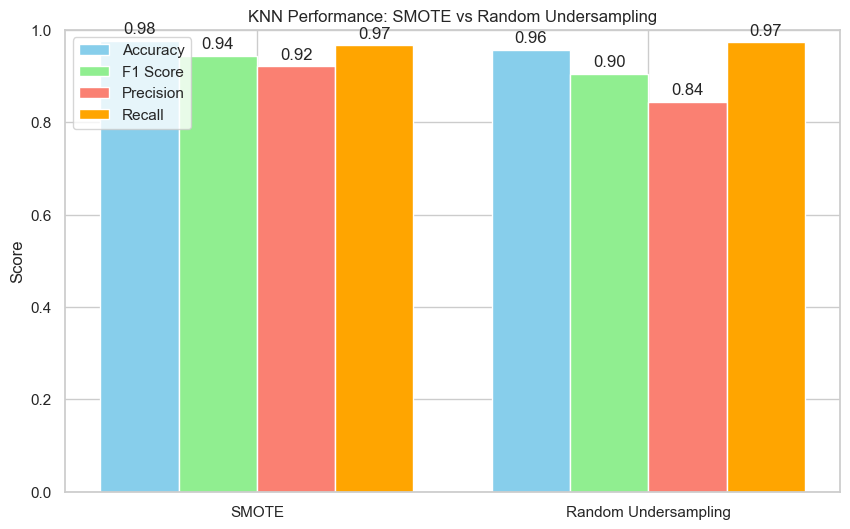

In [109]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Calcul des scores
methods = ['SMOTE', 'Random Undersampling']

accuracy_scores = [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_rus)]
f1_scores = [f1_score(y_test, y_pred), f1_score(y_test, y_pred_rus)]
precision_scores = [precision_score(y_test, y_pred), precision_score(y_test, y_pred_rus)]
recall_scores = [recall_score(y_test, y_pred), recall_score(y_test, y_pred_rus)]

# Création d'un DataFrame pour comparaison
comparison_df = pd.DataFrame({
    'Method': methods,
    'Accuracy': accuracy_scores,
    'F1 Score': f1_scores,
    'Precision': precision_scores,
    'Recall': recall_scores
})

print("Comparaison des performances KNN :")
print(comparison_df)

# Visualisation graphique
x = np.arange(len(methods))  # position des méthodes sur l'axe x
width = 0.2  # largeur des barres

fig, ax = plt.subplots(figsize=(10,6))

rects1 = ax.bar(x - 1.5*width, accuracy_scores, width, label='Accuracy', color='skyblue')
rects2 = ax.bar(x - 0.5*width, f1_scores, width, label='F1 Score', color='lightgreen')
rects3 = ax.bar(x + 0.5*width, precision_scores, width, label='Precision', color='salmon')
rects4 = ax.bar(x + 1.5*width, recall_scores, width, label='Recall', color='orange')

ax.set_ylabel('Score')
ax.set_ylim(0,1)
ax.set_title('KNN Performance: SMOTE vs Random Undersampling')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()

# Affichage des valeurs sur les barres
for rects in [rects1, rects2, rects3, rects4]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.show()


## Decision tree algo

### DecisionTree from scratch

In [110]:
class DecisionTree:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    # Gini Impurity
    def gini(self, y):
        m = len(y)
        counts = np.bincount(y)
        probabilities = counts / m
        return 1 - np.sum(probabilities ** 2)

    # Split the dataset
    def split(self, X, y, feature_index, threshold):
        left_mask = X[:, feature_index] <= threshold
        right_mask = X[:, feature_index] > threshold
        return X[left_mask], y[left_mask], X[right_mask], y[right_mask]

    # Best split (milieux des valeurs triées)
    def best_split(self, X, y):
        m, n = X.shape
        best_gini = 1
        best_feature, best_threshold = None, None

        for feature_index in range(n):
            # Trier les valeurs de la feature
            sorted_values = np.sort(np.unique(X[:, feature_index]))
            # Calculer les milieux entre valeurs consécutives
            thresholds = (sorted_values[:-1] + sorted_values[1:]) / 2  # optimisation

            for t in thresholds:
                X_left, y_left, X_right, y_right = self.split(X, y, feature_index, t)
                if len(y_left) == 0 or len(y_right) == 0:
                    continue
                gini_left = self.gini(y_left)
                gini_right = self.gini(y_right)
                gini_split = (len(y_left) * gini_left + len(y_right) * gini_right) / m
                if gini_split < best_gini:
                    best_gini = gini_split
                    best_feature = feature_index
                    best_threshold = t
        return best_feature, best_threshold

    # Build tree recursively
    def build_tree(self, X, y, depth=0):
        if len(set(y)) == 1 or depth >= self.max_depth or len(y) < self.min_samples_split:
            return Counter(y).most_common(1)[0][0]

        feature, threshold = self.best_split(X, y)
        if feature is None:
            return Counter(y).most_common(1)[0][0]

        X_left, y_left, X_right, y_right = self.split(X, y, feature, threshold)
        left_tree = self.build_tree(X_left, y_left, depth + 1)
        right_tree = self.build_tree(X_right, y_right, depth + 1)

        return {"feature": feature, "threshold": threshold, "left": left_tree, "right": right_tree}

    def fit(self, X, y):
        self.tree = self.build_tree(X, y)

    # Predict one sample
    def predict_one(self, x, node):
        if not isinstance(node, dict):
            return node
        if x[node['feature']] <= node['threshold']:
            return self.predict_one(x, node['left'])
        else:
            return self.predict_one(x, node['right'])

    def predict(self, X):
        return np.array([self.predict_one(x, self.tree) for x in X])


### execution with sklearn


#### avec SMOTE 

In [111]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Assuming X_train_res, y_train_res are your training data (after SMOTE)
# and X_test, y_test are your test data

# Create the Decision Tree classifier
dt = DecisionTreeClassifier(max_depth=8, min_samples_split=10, random_state=42)

# Train the model
dt.fit(X_train_res, y_train_res)

# Make predictions
y_pred_dct = dt.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_dct))
print("F1 Score:", f1_score(y_test, y_pred_dct))
print(classification_report(y_test, y_pred_dct))


Accuracy: 0.9096069563595673
F1 Score: 0.8121957716804301
              precision    recall  f1-score   support

           0       0.98      0.90      0.94     67994
           1       0.71      0.94      0.81     17798

    accuracy                           0.91     85792
   macro avg       0.85      0.92      0.88     85792
weighted avg       0.93      0.91      0.91     85792



c:\Users\HOME\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [112]:
# Sauvegarde des prédictions Decision Tree SMOTE
dt_smote_pred_path = "data/processed/y_pred_dt_smote.pkl"
with open(dt_smote_pred_path, "wb") as f:
    pickle.dump(y_pred_dct, f)
print(f"y_pred Decision Tree SMOTE saved at {dt_smote_pred_path}")


y_pred Decision Tree SMOTE saved at data/processed/y_pred_dt_smote.pkl


#### avec random undersampling

In [113]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Create the Decision Tree classifier
dt = DecisionTreeClassifier(max_depth=8, min_samples_split=10, random_state=42)

# Train the model
dt.fit(X_train_res2, y_train_res2)

# Make predictions
y_pred_dct2 = dt.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_dct2))
print("F1 Score:", f1_score(y_test, y_pred_dct2))
print(classification_report(y_test, y_pred_dct2))


Accuracy: 0.9100615441999254
F1 Score: 0.8126911686167888
              precision    recall  f1-score   support

           0       0.98      0.90      0.94     67994
           1       0.72      0.94      0.81     17798

    accuracy                           0.91     85792
   macro avg       0.85      0.92      0.88     85792
weighted avg       0.93      0.91      0.91     85792



c:\Users\HOME\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [114]:
# Sauvegarde des prédictions Decision Tree RUS
dt_rus_pred_path = "data/processed/y_pred_dt_rus.pkl"
with open(dt_rus_pred_path, "wb") as f:
    pickle.dump(y_pred_dct2, f)
print(f"y_pred Decision Tree RUS saved at {dt_rus_pred_path}")


y_pred Decision Tree RUS saved at data/processed/y_pred_dt_rus.pkl


## Comparasion des deux methodes avec DecisionTree

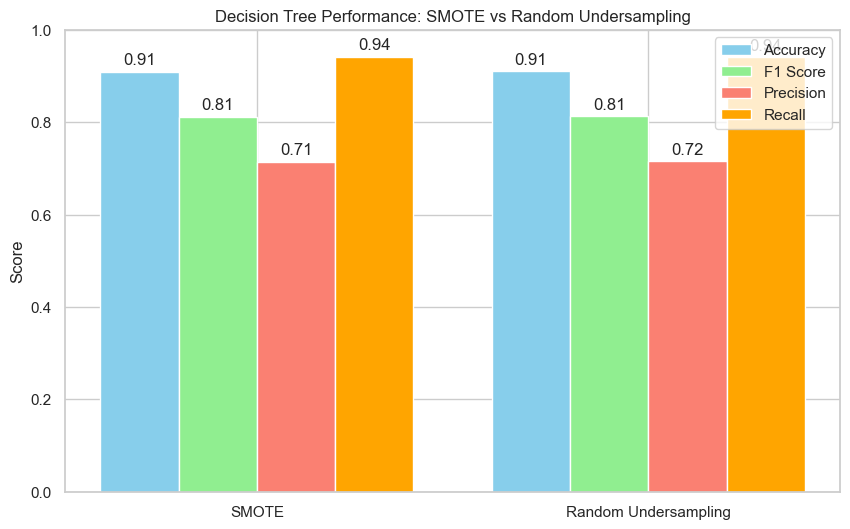

In [116]:
from sklearn.metrics import precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

# Scores pour les deux méthodes
methods = ['SMOTE', 'Random Undersampling']

accuracy_scores = [accuracy_score(y_test, y_pred_dct), accuracy_score(y_test, y_pred_dct2)]
f1_scores = [f1_score(y_test, y_pred_dct), f1_score(y_test, y_pred_dct2)]
precision_scores = [precision_score(y_test, y_pred_dct), precision_score(y_test, y_pred_dct2)]
recall_scores = [recall_score(y_test, y_pred_dct), recall_score(y_test, y_pred_dct2)]

x = np.arange(len(methods))  # position des méthodes sur l'axe x
width = 0.2  # largeur des barres

fig, ax = plt.subplots(figsize=(10,6))

# Barres pour chaque métrique
rects1 = ax.bar(x - 1.5*width, accuracy_scores, width, label='Accuracy', color='skyblue')
rects2 = ax.bar(x - 0.5*width, f1_scores, width, label='F1 Score', color='lightgreen')
rects3 = ax.bar(x + 0.5*width, precision_scores, width, label='Precision', color='salmon')
rects4 = ax.bar(x + 1.5*width, recall_scores, width, label='Recall', color='orange')

# Labels et titres
ax.set_ylabel('Score')
ax.set_ylim(0,1)
ax.set_title('Decision Tree Performance: SMOTE vs Random Undersampling')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()

# Afficher les valeurs sur les barres
for rects in [rects1, rects2, rects3, rects4]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.show()


## Random Forest 

### Random Forest from scratch

In [118]:
import numpy as np
from collections import Counter

class RandomForest:
    def __init__(self, n_trees=10, max_depth=5, min_samples_split=2, max_features='sqrt', bootstrap=True):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.trees = []

    # Gini Impurity
    def gini(self, y):
        m = len(y)
        if m == 0:
            return 0
        counts = np.bincount(y)
        probabilities = counts / m
        return 1 - np.sum(probabilities ** 2)

    # Split dataset
    def split(self, X, y, feature_index, threshold):
        left_mask = X[:, feature_index] <= threshold
        right_mask = X[:, feature_index] > threshold
        return X[left_mask], y[left_mask], X[right_mask], y[right_mask]

    # Best split with middle thresholds
    def best_split(self, X, y):
        m, n = X.shape
        best_gini = 1
        best_feature, best_threshold = None, None

        # Select subset of features
        if self.max_features == 'sqrt':
            k = max(1, int(np.sqrt(n)))
            features_idx = np.random.choice(n, k, replace=False)
        elif isinstance(self.max_features, int):
            features_idx = np.random.choice(n, self.max_features, replace=False)
        else:
            features_idx = np.arange(n)  # all features

        for feature_index in features_idx:
            sorted_values = np.sort(np.unique(X[:, feature_index]))
            # use midpoints for thresholds
            thresholds = (sorted_values[:-1] + sorted_values[1:]) / 2
            for t in thresholds:
                X_left, y_left, X_right, y_right = self.split(X, y, feature_index, t)
                if len(y_left) == 0 or len(y_right) == 0:
                    continue
                gini_left = self.gini(y_left)
                gini_right = self.gini(y_right)
                gini_split = (len(y_left) * gini_left + len(y_right) * gini_right) / m
                if gini_split < best_gini:
                    best_gini = gini_split
                    best_feature = feature_index
                    best_threshold = t

        return best_feature, best_threshold

    # Build tree recursively
    def build_tree(self, X, y, depth=0):
        if len(set(y)) == 1 or depth >= self.max_depth or len(y) < self.min_samples_split:
            return Counter(y).most_common(1)[0][0]

        feature, threshold = self.best_split(X, y)
        if feature is None:
            return Counter(y).most_common(1)[0][0]

        X_left, y_left, X_right, y_right = self.split(X, y, feature, threshold)
        left_tree = self.build_tree(X_left, y_left, depth + 1)
        right_tree = self.build_tree(X_right, y_right, depth + 1)

        return {"feature": feature, "threshold": threshold, "left": left_tree, "right": right_tree}

    # Fit single tree
    def fit_tree(self, X, y):
        return self.build_tree(X, y)

    # Fit Random Forest
    def fit(self, X, y):
        self.trees = []
        for _ in range(self.n_trees):
            if self.bootstrap:
                idxs = np.random.choice(len(X), len(X), replace=True)
                X_sample = X[idxs]
                y_sample = y[idxs]
            else:
                X_sample = X
                y_sample = y
            tree = self.fit_tree(X_sample, y_sample)
            self.trees.append(tree)

    # Predict one sample using a tree
    def predict_one_tree(self, x, node):
        if not isinstance(node, dict):
            return node
        if x[node['feature']] <= node['threshold']:
            return self.predict_one_tree(x, node['left'])
        else:
            return self.predict_one_tree(x, node['right'])

    # Predict all trees and vote
    def predict(self, X):
        all_preds = []
        for tree in self.trees:
            preds = [self.predict_one_tree(x, tree) for x in X]
            all_preds.append(preds)
        # Transpose and majority vote
        all_preds = np.array(all_preds).T
        final_preds = [Counter(row).most_common(1)[0][0] for row in all_preds]
        return np.array(final_preds)


### Random Forest avec SKLEARN

### classical Random Forest

#### Sans imbalance

In [117]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Créer le Random Forest
rf = RandomForestClassifier(
    n_estimators=100,       # nombre d'arbres
    max_depth=None,         # profondeur maximale
    random_state=42,
    n_jobs=-1
)

# Entraîner sur le train set original
rf.fit(X_train, y_train)

# Prédire sur le test set
y_pred_rf = rf.predict(X_test)

# Évaluation
print("Random Forest (train set original, sans rééquilibrage)")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest (train set original, sans rééquilibrage)
Accuracy: 0.9893579820962327
F1 Score: 0.9743070212466582
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     67994
           1       0.98      0.97      0.97     17798

    accuracy                           0.99     85792
   macro avg       0.98      0.98      0.98     85792
weighted avg       0.99      0.99      0.99     85792



In [119]:
# Sauvegarde des prédictions RF Original
rf_orig_pred_path = "data/processed/y_pred_rf_original.pkl"
with open(rf_orig_pred_path, "wb") as f:
    pickle.dump(y_pred_rf, f)
print(f"y_pred RF Original saved at {rf_orig_pred_path}")


y_pred RF Original saved at data/processed/y_pred_rf_original.pkl


#### Avec SMOTE Oversampling

In [120]:
# Créer le Random Forest
rf_smote = RandomForestClassifier(
    n_estimators=100,       # nombre d'arbres
    max_depth=None,         # profondeur maximale
    random_state=42,
    n_jobs=-1
)

# Entraîner le modèle sur l'ensemble SMOTE
rf_smote.fit(X_train_res, y_train_res)

# Prédire sur le test set (non rééchantillonné)
y_pred_rf_smote = rf_smote.predict(X_test)

# Évaluation
print("Random Forest Classique (SMOTE Oversampling)")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_smote))
print("F1 Score:", f1_score(y_test, y_pred_rf_smote))
print(classification_report(y_test, y_pred_rf_smote))

c:\Users\HOME\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Random Forest Classique (SMOTE Oversampling)
Accuracy: 0.9886236478925774
F1 Score: 0.9725888895130034
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     67994
           1       0.97      0.97      0.97     17798

    accuracy                           0.99     85792
   macro avg       0.98      0.98      0.98     85792
weighted avg       0.99      0.99      0.99     85792



In [122]:
# Sauvegarde des prédictions RF SMOTE
rf_smote_pred_path = "data/processed/y_pred_rf_smote.pkl"
with open(rf_smote_pred_path, "wb") as f:
    pickle.dump(y_pred_rf_smote, f)
print(f"y_pred RF SMOTE saved at {rf_smote_pred_path}")


y_pred RF SMOTE saved at data/processed/y_pred_rf_smote.pkl


### Balanced Random Forest

"pas besoin de imbalance ici on utilise directement le dataset originale car 
on a class_weight='balanced'  # pondération automatique des classes "

In [123]:

rf_balanced = RandomForestClassifier(
    n_estimators=100,        # nombre d'arbres
    max_depth=None,          # profondeur maximale
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # pondération automatique des classes
)

# Entraîner sur le train set original
rf_balanced.fit(X_train, y_train)

# Prédire sur le test set
y_pred_rf_balanced = rf_balanced.predict(X_test)

# Évaluation
print("Balanced Random Forest (train set original, class_weight='balanced')")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_balanced))
print("F1 Score:", f1_score(y_test, y_pred_rf_balanced))
print(classification_report(y_test, y_pred_rf_balanced))


Balanced Random Forest (train set original, class_weight='balanced')
Accuracy: 0.9892763894069377
F1 Score: 0.9741151313938439
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     67994
           1       0.98      0.97      0.97     17798

    accuracy                           0.99     85792
   macro avg       0.98      0.98      0.98     85792
weighted avg       0.99      0.99      0.99     85792



In [124]:
# Sauvegarde des prédictions RF Balanced
rf_balanced_pred_path = "data/processed/y_pred_rf_balanced.pkl"
with open(rf_balanced_pred_path, "wb") as f:
    pickle.dump(y_pred_rf_balanced, f)
print(f"y_pred RF Balanced saved at {rf_balanced_pred_path}")


y_pred RF Balanced saved at data/processed/y_pred_rf_balanced.pkl


### Comparaison entre les trois 

Comparaison des performances Random Forest :
                  Method  Accuracy  F1 Score  Precision    Recall
0  RF Classique Original  0.989358  0.974307   0.975982  0.972637
1     RF Classique SMOTE  0.988624  0.972589   0.972316  0.972862
2            RF Balanced  0.989276  0.974115   0.975597  0.972637


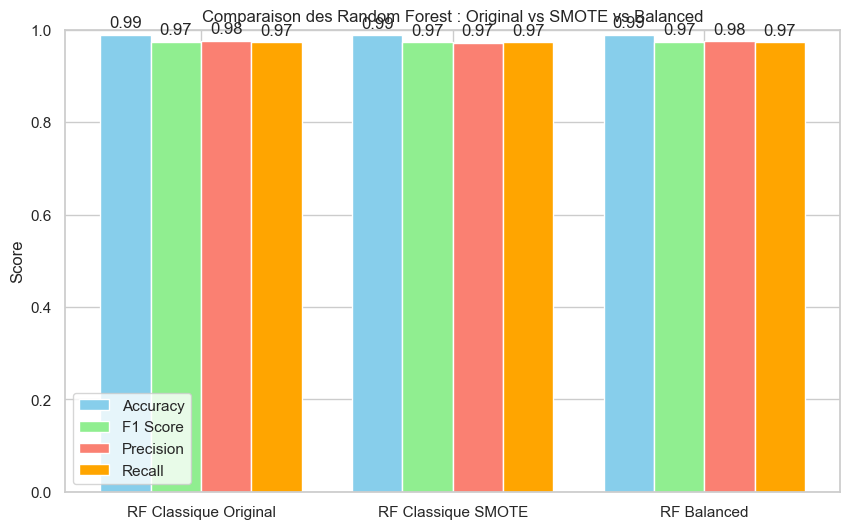

In [125]:

# Calcul des métriques
methods = ['RF Classique Original', 'RF Classique SMOTE', 'RF Balanced']

accuracy_scores = [
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_rf_smote),
    accuracy_score(y_test, y_pred_rf_balanced)
]

f1_scores = [
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf_smote),
    f1_score(y_test, y_pred_rf_balanced)
]

precision_scores = [
    precision_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf_smote),
    precision_score(y_test, y_pred_rf_balanced)
]

recall_scores = [
    recall_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf_smote),
    recall_score(y_test, y_pred_rf_balanced)
]

# DataFrame pour affichage
comparison_df = pd.DataFrame({
    'Method': methods,
    'Accuracy': accuracy_scores,
    'F1 Score': f1_scores,
    'Precision': precision_scores,
    'Recall': recall_scores
})

print("Comparaison des performances Random Forest :")
print(comparison_df)


# Visualisation graphique

x = range(len(methods))
width = 0.2

fig, ax = plt.subplots(figsize=(10,6))

rects1 = ax.bar([i - width*1.5 for i in x], accuracy_scores, width, label='Accuracy', color='skyblue')
rects2 = ax.bar([i - width/2 for i in x], f1_scores, width, label='F1 Score', color='lightgreen')
rects3 = ax.bar([i + width/2 for i in x], precision_scores, width, label='Precision', color='salmon')
rects4 = ax.bar([i + width*1.5 for i in x], recall_scores, width, label='Recall', color='orange')

ax.set_ylabel('Score')
ax.set_ylim(0,1)
ax.set_title('Comparaison des Random Forest : Original vs SMOTE vs Balanced')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()

# Afficher les valeurs sur les barres
for rects in [rects1, rects2, rects3, rects4]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.show()


## Comparaison entre les 3 modeles knnn decisiontree et random forest

Comparaison globale des modèles :
                 Model  Accuracy  F1 Score  Precision    Recall
0            KNN SMOTE  0.975930  0.943383   0.921232  0.966625
1              KNN RUS  0.957222  0.904203   0.844384  0.973143
2  Decision Tree SMOTE  0.909607  0.812196   0.713726  0.942185
3    Decision Tree RUS  0.910062  0.812691   0.715464  0.940499
4          RF Original  0.989358  0.974307   0.975982  0.972637
5             RF SMOTE  0.988624  0.972589   0.972316  0.972862
6          RF Balanced  0.989276  0.974115   0.975597  0.972637


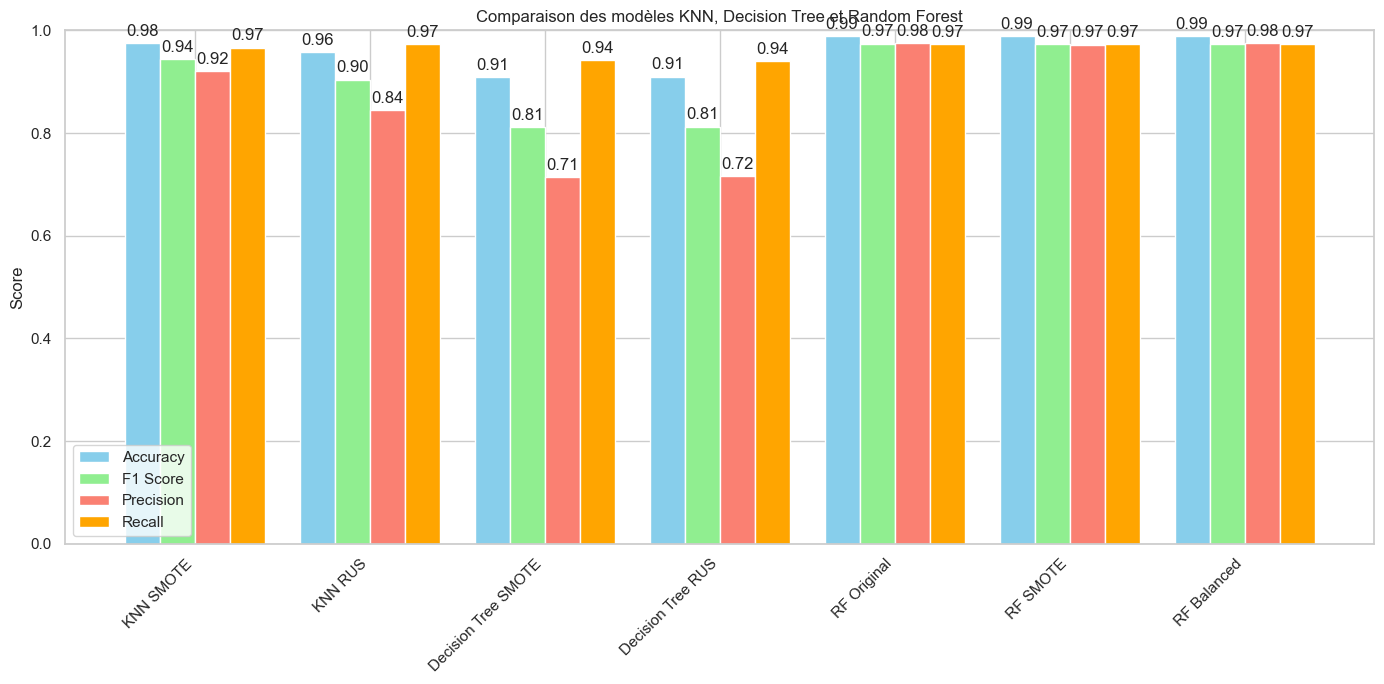

In [126]:

# calculer les scores pour chaque modèle

methods = [
    'KNN SMOTE', 'KNN RUS',
    'Decision Tree SMOTE', 'Decision Tree RUS',
    'RF Original', 'RF SMOTE', 'RF Balanced'
]

accuracy_scores = [
    accuracy_score(y_test, y_pred),       # KNN SMOTE
    accuracy_score(y_test, y_pred_rus),  # KNN RUS
    accuracy_score(y_test, y_pred_dct),  # DT SMOTE
    accuracy_score(y_test, y_pred_dct2), # DT RUS
    accuracy_score(y_test, y_pred_rf),       # RF Original
    accuracy_score(y_test, y_pred_rf_smote), # RF SMOTE
    accuracy_score(y_test, y_pred_rf_balanced) # RF Balanced
]

f1_scores = [
    f1_score(y_test, y_pred),
    f1_score(y_test, y_pred_rus),
    f1_score(y_test, y_pred_dct),
    f1_score(y_test, y_pred_dct2),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf_smote),
    f1_score(y_test, y_pred_rf_balanced)
]

precision_scores = [
    precision_score(y_test, y_pred),
    precision_score(y_test, y_pred_rus),
    precision_score(y_test, y_pred_dct),
    precision_score(y_test, y_pred_dct2),
    precision_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf_smote),
    precision_score(y_test, y_pred_rf_balanced)
]

recall_scores = [
    recall_score(y_test, y_pred),
    recall_score(y_test, y_pred_rus),
    recall_score(y_test, y_pred_dct),
    recall_score(y_test, y_pred_dct2),
    recall_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf_smote),
    recall_score(y_test, y_pred_rf_balanced)
]

# créer le DataFrame comparatif

comparison_df = pd.DataFrame({
    'Model': methods,
    'Accuracy': accuracy_scores,
    'F1 Score': f1_scores,
    'Precision': precision_scores,
    'Recall': recall_scores
})

print("Comparaison globale des modèles :")
print(comparison_df)

# visualisation graphique

x = np.arange(len(methods))
width = 0.2

fig, ax = plt.subplots(figsize=(14,7))

rects1 = ax.bar(x - 1.5*width, accuracy_scores, width, label='Accuracy', color='skyblue')
rects2 = ax.bar(x - 0.5*width, f1_scores, width, label='F1 Score', color='lightgreen')
rects3 = ax.bar(x + 0.5*width, precision_scores, width, label='Precision', color='salmon')
rects4 = ax.bar(x + 1.5*width, recall_scores, width, label='Recall', color='orange')

ax.set_ylabel('Score')
ax.set_ylim(0,1)
ax.set_title('Comparaison des modèles KNN, Decision Tree et Random Forest')
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=45, ha='right')
ax.legend()

# Ajouter les valeurs sur les barres
for rects in [rects1, rects2, rects3, rects4]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [69]:
#saving

In [127]:
# Folder path
save_dir = "data/processed"
os.makedirs(save_dir, exist_ok=True)  # Create folder if it doesn't exist

# File path
save_path = os.path.join(save_dir, "df_encoded.pkl")

# Save silently
with open(save_path, "wb") as f:
    pickle.dump(df_encoded, f);

## DBSCAN

In [141]:
X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy()


In [142]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from collections import Counter

# Échantillon pour silhouette 
sample_size = min(10000, len(X_train_np))
sample_indices = np.random.choice(len(X_train_np), sample_size, replace=False)
X_sample = X_train_np[sample_indices]

In [143]:
eps_values = [0.3, 0.5, 0.7]
min_samples_values = [5, 10, 15]
metrics = ['euclidean', 'manhattan']

best_score = -1
best_params = None

In [ ]:
for metric in metrics:
    for eps in eps_values:
        for min_samples in min_samples_values:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=metric)
            labels_sample = dbscan.fit_predict(X_sample)

            # Nombre de clusters et pourcentage de bruit
            n_clusters = len(set(labels_sample)) - (1 if -1 in labels_sample else 0)
            noise_pct = np.sum(labels_sample == -1) / len(labels_sample)

            print(f"metric={metric}, eps={eps}, min_samples={min_samples}, clusters={n_clusters}, noise={noise_pct:.2f}")

            
            # le nombre de clusters > 1 et le pourcentage de bruit le plus faible
            if n_clusters > 1 and (best_score == -1 or noise_pct < best_score):
                best_score = noise_pct  # on garde le plus faible bruit
                best_params = {'metric': metric, 'eps': eps, 'min_samples': min_samples}

print("\nMeilleurs paramètres DBSCAN:", best_params)


metric=euclidean, eps=0.7, min_samples=10, clusters=44, noise=0.94
metric=euclidean, eps=0.7, min_samples=15, clusters=12, noise=0.98
metric=euclidean, eps=0.7, min_samples=20, clusters=5, noise=0.99
metric=euclidean, eps=0.7999999999999999, min_samples=10, clusters=45, noise=0.94
metric=euclidean, eps=0.7999999999999999, min_samples=15, clusters=12, noise=0.98
metric=euclidean, eps=0.7999999999999999, min_samples=20, clusters=5, noise=0.99
metric=euclidean, eps=0.8999999999999999, min_samples=10, clusters=45, noise=0.94
metric=euclidean, eps=0.8999999999999999, min_samples=15, clusters=13, noise=0.97
metric=euclidean, eps=0.8999999999999999, min_samples=20, clusters=6, noise=0.98
metric=euclidean, eps=0.9999999999999999, min_samples=10, clusters=48, noise=0.92
metric=euclidean, eps=0.9999999999999999, min_samples=15, clusters=14, noise=0.97
metric=euclidean, eps=0.9999999999999999, min_samples=20, clusters=5, noise=0.98
metric=euclidean, eps=1.0999999999999999, min_samples=10, cluster

In [147]:
dbscan_final = DBSCAN(
    eps=best_params['eps'], 
    min_samples=best_params['min_samples'], 
    metric=best_params['metric']
)
final_labels = dbscan_final.fit_predict(X_train_np)

In [148]:
cluster_to_class = {}
for cluster in set(final_labels):
    if cluster == -1:
        continue  # ignorer le bruit
    mask = final_labels == cluster
    majority_class = Counter(y_train_np[mask]).most_common(1)[0][0]
    cluster_to_class[cluster] = majority_class


In [149]:
centroids = {c: X_train_np[final_labels == c].mean(axis=0) for c in cluster_to_class}


In [153]:

X_test_np = X_test.to_numpy()  
y_test_np = y_test.to_numpy()  


In [ ]:
def dbscan_predict_memory_safe(X, centroids, cluster_to_class):
    preds = []
    for x in X:
        # calculer distance à chaque centroid
        min_dist = float('inf')
        closest_cluster = None
        for c, centroid in centroids.items():
            dist = np.linalg.norm(x - centroid)
            if dist < min_dist:
                min_dist = dist
                closest_cluster = c
        preds.append(cluster_to_class[closest_cluster])
    return np.array(preds)

# Utilisation
y_pred_dbscan = dbscan_predict_memory_safe(X_test_np, centroids, cluster_to_class)


In [159]:
# Utilisation
y_pred_dbscan = dbscan_predict_memory_safe(X_test_np, centroids, cluster_to_class)

In [160]:
dbscan_pred_path = "data/processed/y_pred_dbscan.pkl"
with open(dbscan_pred_path, "wb") as f:
    pickle.dump(y_pred_dbscan, f)

print(f"y_pred DBSCAN saved at {dbscan_pred_path}")


y_pred DBSCAN saved at data/processed/y_pred_dbscan.pkl


In [161]:
labels = dbscan_final.fit_predict(X_train_np)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Nombre de clusters :", n_clusters)


Nombre de clusters : 4619


In [163]:
# Taux de bruit (entre 0 et 1)
noise_ratio = np.mean(labels == -1)

# Pourcentage de bruit
noise_percentage = noise_ratio * 100

print(f"Taux de bruit : {noise_ratio:.4f}")
print(f"Pourcentage de bruit : {noise_percentage:.2f} %")


Taux de bruit : 0.4956
Pourcentage de bruit : 49.56 %


In [165]:
from collections import Counter

cluster_sizes = Counter(labels)
cluster_sizes.pop(-1, None)  # enlever bruit

mean_cluster_size = np.mean(list(cluster_sizes.values()))
print("Taille moyenne des clusters :", mean_cluster_size)


Taille moyenne des clusters : 37.47759255250054


In [166]:
useful_points = np.sum(labels != -1)
cluster_density_ratio = n_clusters / useful_points

print("Ratio clusters / points utiles :", cluster_density_ratio)


Ratio clusters / points utiles : 0.026682610378432087


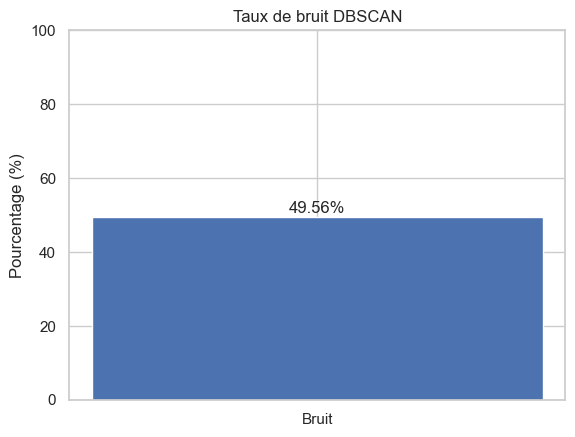

In [167]:
plt.bar(["Bruit"], [noise_percentage])
plt.ylabel("Pourcentage (%)")
plt.title("Taux de bruit DBSCAN")

plt.text(0, noise_percentage + 1, f"{noise_percentage:.2f}%", ha='center')
plt.ylim(0, 100)
plt.show()


## From scratch

Dans le TP :

Pour DBSCAN sklearn, on évalue les clusters et le bruit sur le training set.

La “prédiction” sur X_test que j'ai faite faite avec les centroids est une méthode approximative, mais ce n’est pas du DBSCAN pur.  (LI KHDATLI 1H PEUT NKHALOHA EN PLUS 7A9 UNE HEURE )

In [ ]:
import numpy as np
from collections import deque

class DBSCANScratch:
    def __init__(self, eps=0.5, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples
        self.labels_ = None

    def fit(self, X):
        n_samples = X.shape[0]
        self.labels_ = -1 * np.ones(n_samples, dtype=int)  # Tout initialement bruit
        cluster_id = 0
        visited = np.zeros(n_samples, dtype=bool)

        for i in range(n_samples):
            if visited[i]:
                continue
            visited[i] = True
            neighbors = self.region_query(X, i)

            if len(neighbors) < self.min_samples:
                # bruit, label reste -1
                continue
            # Sinon, on a un nouveau cluster
            self.expand_cluster(X, i, neighbors, cluster_id, visited)
            cluster_id += 1
        return self

    def region_query(self, X, idx):
        """Retourne les indices des points dans le rayon eps autour de X[idx]"""
        point = X[idx]
        # Calcul des distances euclidiennes
        distances = np.linalg.norm(X - point, axis=1)
        neighbors = np.where(distances <= self.eps)[0]
        return neighbors.tolist()

    def expand_cluster(self, X, idx, neighbors, cluster_id, visited):
        self.labels_[idx] = cluster_id
        queue = deque(neighbors)
        while queue:
            j = queue.popleft()
            if not visited[j]:
                visited[j] = True
                j_neighbors = self.region_query(X, j)
                if len(j_neighbors) >= self.min_samples:
                    queue.extend(j_neighbors)
            if self.labels_[j] == -1:
                self.labels_[j] = cluster_id

# Exemple d'utilisation
db_scratch = DBSCANScratch(eps=0.7, min_samples=10)
db_scratch.fit(X_train_np)
labels_scratch = db_scratch.labels_

# Nombre de clusters
n_clusters_scratch = len(set(labels_scratch)) - (1 if -1 in labels_scratch else 0)
noise_ratio_scratch = np.mean(labels_scratch == -1)

print("DBSCAN from scratch")
print("Nombre de clusters :", n_clusters_scratch)
print(f"Taux de bruit : {noise_ratio_scratch:.4f}")


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Pour sklearn DBSCAN
labels_sklearn = dbscan_final.fit_predict(X_train_np)

print("Silhouette (sklearn) :", silhouette_score(X_train_np, labels_sklearn))
print("Silhouette (scratch) :", silhouette_score(X_train_np, labels_scratch))

print("Davies-Bouldin (sklearn) :", davies_bouldin_score(X_train_np, labels_sklearn))
print("Davies-Bouldin (scratch) :", davies_bouldin_score(X_train_np, labels_scratch))

print("Calinski-Harabasz (sklearn) :", calinski_harabasz_score(X_train_np, labels_sklearn))
print("Calinski-Harabasz (scratch) :", calinski_harabasz_score(X_train_np, labels_scratch))


## K-MEANS

Features only (no target)

In [14]:
X_kmeans = df_encoded.copy()

Keep numeric columns only

In [15]:
numeric_cols = X_kmeans.select_dtypes(
    include=['float64', 'float32', 'int64']
).columns

X_kmeans = X_kmeans[numeric_cols]

Scale using the FULL dataset

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_kmeans_scaled = scaler.fit_transform(X_kmeans)

In [17]:
X_np = X_kmeans_scaled  # already NumPy after scaling


CH computation function for k hypertuning

In [19]:
from sklearn.metrics import calinski_harabasz_score
from sklearn.cluster import KMeans
def compute_CH(X, labels):
    """
    Compute Calinski-Harabasz score for given clustering.
    """
    return calinski_harabasz_score(X, labels)


In [21]:
K_values = range(2, 11)  # try K = 2 → 10
CH_scores = []

# Optional: sample subset for speed
sample_size = 50000
if X_np.shape[0] > sample_size:
    idx = np.random.choice(X_np.shape[0], size=sample_size, replace=False)
    X_sample = X_np[idx]
else:
    X_sample = X_np

for K in K_values:
    print(f"Testing K={K}...")
    
    kmeans = KMeans(
        n_clusters=K, 
        init='k-means++', 
        n_init=10,         # number of random restarts
        max_iter=100, 
        random_state=42
    )
    
    labels = kmeans.fit_predict(X_sample)
    ch = calinski_harabasz_score(X_sample, labels)
    CH_scores.append(ch)
    print(f"  CH score = {ch:.2f}")


Testing K=2...
  CH score = 10896.02
Testing K=3...
  CH score = 8339.54
Testing K=4...
  CH score = 7212.03
Testing K=5...
  CH score = 6646.62
Testing K=6...
  CH score = 6203.50
Testing K=7...
  CH score = 5885.70
Testing K=8...
  CH score = 5602.67
Testing K=9...
  CH score = 4967.09
Testing K=10...
  CH score = 4937.72


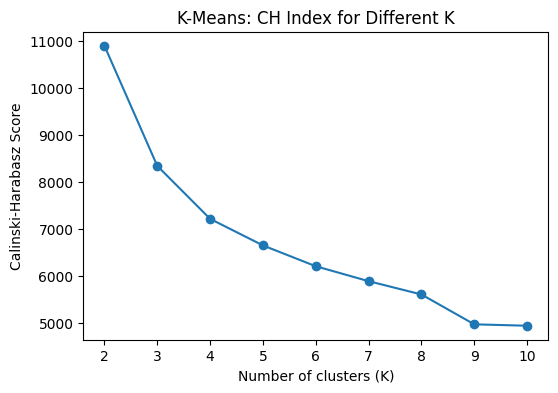

In [22]:
plt.figure(figsize=(6,4))
plt.plot(K_values, CH_scores, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Calinski-Harabasz Score")
plt.title("K-Means: CH Index for Different K")
plt.show()

elbow method:

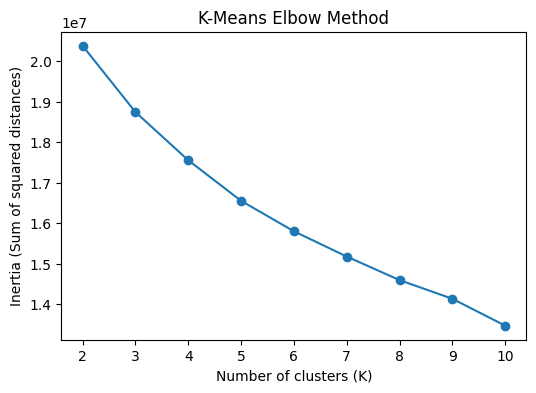

In [23]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia_values = []

for K in range(2, 11):
    kmeans = KMeans(
        n_clusters=K,
        init='k-means++',
        n_init=10,
        max_iter=100,
        random_state=42
    )
    kmeans.fit(X_np)
    inertia_values.append(kmeans.inertia_)  # sum of squared distances to centroids

# Plot
plt.figure(figsize=(6,4))
plt.plot(range(2, 11), inertia_values, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia (Sum of squared distances)")
plt.title("K-Means Elbow Method")
plt.show()


In [24]:
print(inertia_values)


[20381539.608856417, 18745372.787044637, 17553770.43757431, 16551566.242143184, 15799019.204253323, 15175488.029536914, 14593195.945061086, 14131863.047581237, 13467100.246996384]


```To determine the optimal number of clusters (K) for our K-Means clustering, we used two methods: the Calinski–Harabasz (CH) index and the Elbow method. The CH index measures the ratio of between-cluster variance to within-cluster variance, with higher values indicating more compact and well-separated clusters. We tested K values from 2 to 10 and found that the CH index was maximized at K=2, suggesting that the dataset naturally splits into two main clusters. We also computed the inertia (sum of squared distances to centroids) for the same range of K values to apply the Elbow method. The largest drop in inertia occurs at K=2, with subsequent reductions becoming progressively smaller, which visually supports the choice of K=2. Based on these results, we selected K=2 as the optimal number of clusters, and fitted K-Means to the full dataset to assign cluster labels. This approach ensures that the clusters are compact, well-separated, and interpretable in relation to the dataset’s features.```

checking for k=2

In [25]:
from sklearn.cluster import KMeans

# Define number of clusters
K = 2

# Initialize KMeans
kmeans = KMeans(
    n_clusters=K,        # number of clusters
    init='k-means++',    # smart initialization
    n_init=10,           # number of random restarts
    max_iter=100,        # max iterations per run
    random_state=42      # reproducibility
)

# Fit KMeans and get cluster labels
labels = kmeans.fit_predict(X_np)

# Add cluster labels to your dataframe
df_all['cluster'] = labels

# Optional: check cluster sizes
print(df_all['cluster'].value_counts())

# Optional: check cluster feature means for interpretation
print(df_all.groupby('cluster')[numeric_cols].mean())


cluster
0    325970
1    102989
Name: count, dtype: int64
         prec_winter  prec_spring  prec_summer  prec_fall  tmax_winter  \
cluster                                                                  
0           3.205983     3.718293     0.952672   5.204357    20.481104   
1          35.352798    18.881880     6.071580  26.218031    14.938118   

         tmax_spring  tmax_summer  tmax_fall  tmin_winter  tmin_spring  ...  \
cluster                                                                 ...   
0          31.380590    42.694790  32.099327     6.200634    16.178043  ...   
1          22.664061    34.523827  25.013081     4.796099    10.391465  ...   

         LCCCode_21497-15045  LCCCode_21499-121340  LCCCode_21518  \
cluster                                                             
0                   0.000000              0.000000       0.000006   
1                   0.000068              0.001495       0.007078   

         LCCCode_6001  LCCCode_6004  LCCCode_6020  

```
Cluster 0: Hot, dry, sandy, most of the data (~3/4 of points) → “typical area

Cluster 1: Cooler, wetter, clay-heavy soils (~1/4 of points) → “extreme / higher-risk areas```


```Although the Calinski–Harabasz index is maximized at K=2, we chose K=4 for clustering to capture more nuanced environmental patterns in the dataset. K=2 separates the dataset into broad ‘typical’ and ‘extreme’ regions, but our large dataset contains subtle variations in precipitation, temperature, and soil characteristics that are important for practical interpretation. K=4 allows us to distinguish these variations while keeping cluster sizes reasonable, providing actionable insights for environmental analysis and fire risk assessment.```

In [26]:
from sklearn.cluster import KMeans
import pandas as pd

# ------------------------------
# 1. Define number of clusters
# ------------------------------
K = 4

# ------------------------------
# 2. Initialize and fit KMeans
# ------------------------------
kmeans = KMeans(
    n_clusters=K,
    init='k-means++',   # smart centroid initialization
    n_init=10,          # number of random restarts
    max_iter=100,
    random_state=42
)

# Fit KMeans and predict cluster labels
labels = kmeans.fit_predict(X_np)

# ------------------------------
# 3. Assign cluster labels to dataframe
# ------------------------------
df_all['cluster'] = labels

# ------------------------------
# 4. Inspect cluster sizes
# ------------------------------
print("Cluster sizes:")
print(df_all['cluster'].value_counts())

# ------------------------------
# 5. Inspect cluster feature means
# ------------------------------
print("\nCluster feature means:")
print(df_all.groupby('cluster')[numeric_cols].mean())

# ------------------------------
# 6. Inspect fire risk per cluster
# ------------------------------
print("\nMean fire occurrence per cluster:")
print(df_all.groupby('cluster')['fire'].mean())


Cluster sizes:
cluster
2    221871
3     90107
0     59213
1     57768
Name: count, dtype: int64

Cluster feature means:
         prec_winter  prec_spring  prec_summer  prec_fall  tmax_winter  \
cluster                                                                  
0           4.374002     4.656290     1.724033   8.166417    19.679293   
1           5.076082     4.988833     1.745524   7.573295    19.751261   
2           2.981259     3.537972     0.852852   4.546038    20.582907   
3          38.535473    20.062780     6.033989  27.377974    14.889814   

         tmax_spring  tmax_summer  tmax_fall  tmin_winter  tmin_spring  ...  \
cluster                                                                 ...   
0          30.116196    41.758175  30.823620     6.163835    15.514151  ...   
1          30.097000    41.413311  31.042717     5.957937    15.276686  ...   
2          31.636889    42.926003  32.344070     6.151383    16.290253  ...   
3          22.440634    34.223419  24.9

In [29]:
# ------------------------------
# Settings
# ------------------------------
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\712954804.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster', data=df_all, palette='Set2')


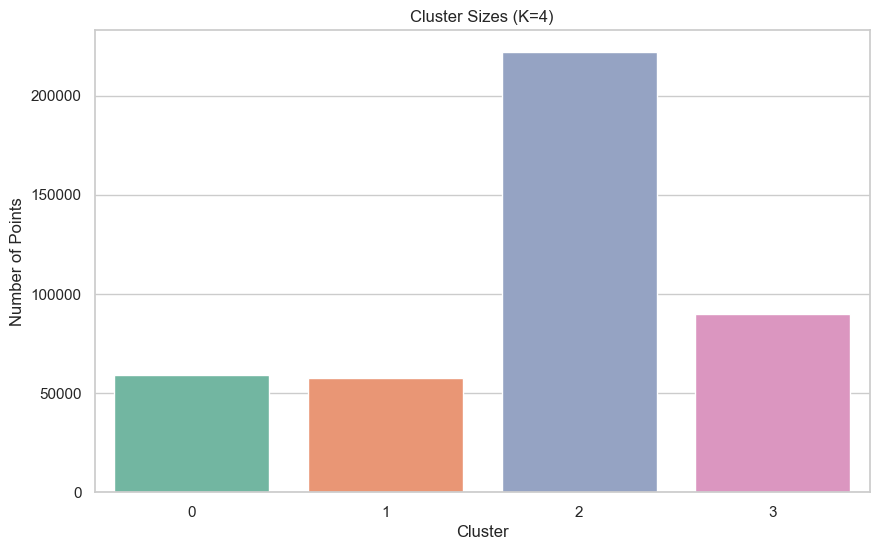

In [30]:
# ------------------------------
# 1. Cluster sizes
# ------------------------------
plt.figure()
sns.countplot(x='cluster', data=df_all, palette='Set2')
plt.title("Cluster Sizes (K=4)")
plt.xlabel("Cluster")
plt.ylabel("Number of Points")
plt.show()


C:\Users\dell\AppData\Local\Temp\ipykernel_16736\3400940874.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fire_perc.index, y=fire_perc.values, palette='Set1')


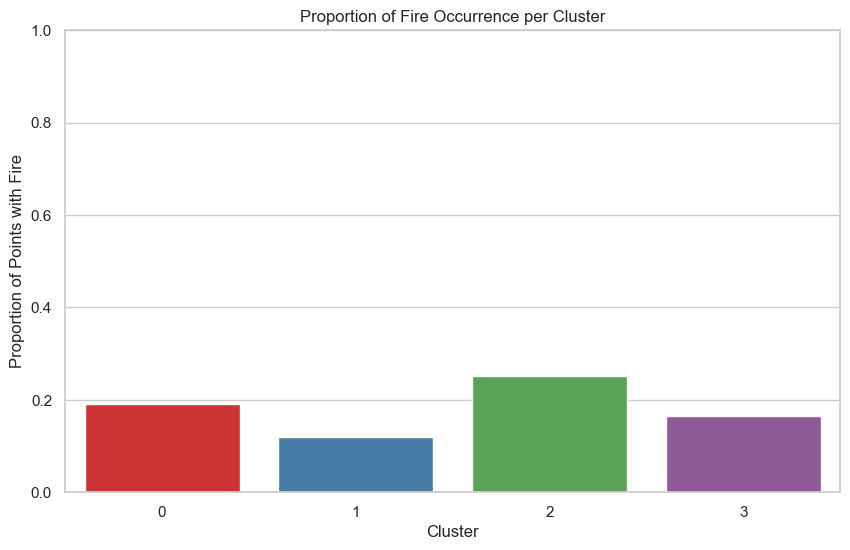

In [31]:
# ------------------------------
# 2. Fire proportion per cluster
# ------------------------------
fire_perc = df_all.groupby('cluster')['fire'].mean()
plt.figure()
sns.barplot(x=fire_perc.index, y=fire_perc.values, palette='Set1')
plt.title("Proportion of Fire Occurrence per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Proportion of Points with Fire")
plt.ylim(0,1)
plt.show()

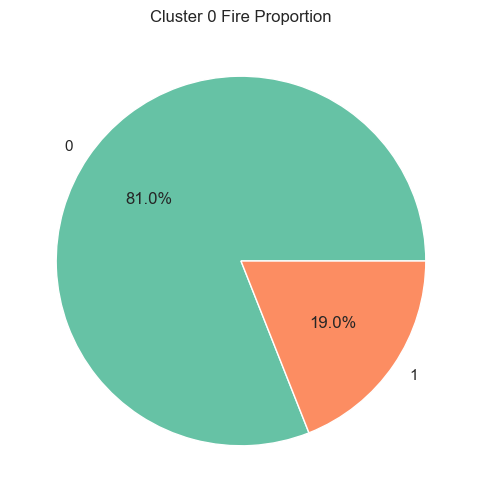

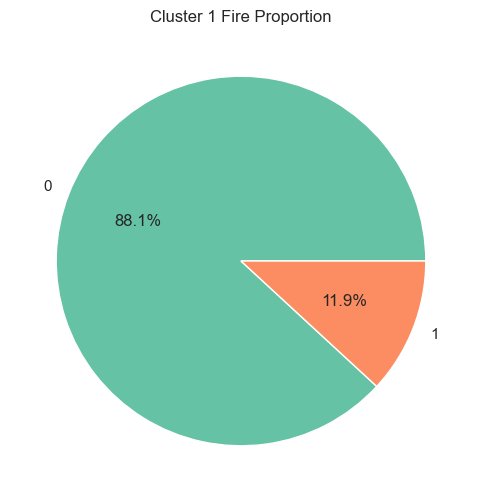

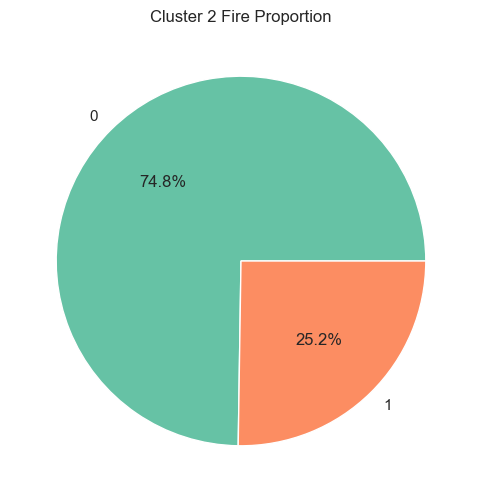

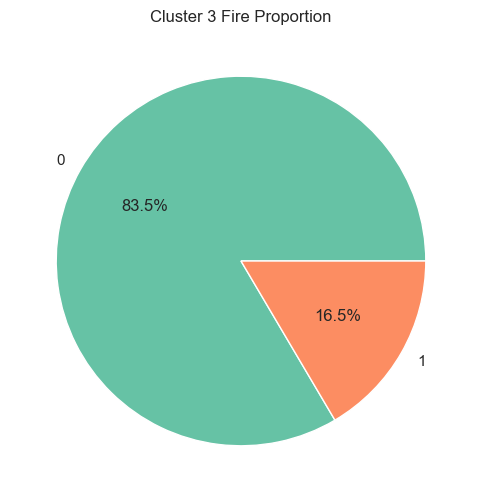

In [32]:
# ------------------------------
# 3. Fire proportion pie charts per cluster
# ------------------------------
for c in range(4):
    cluster_fire = df_all[df_all['cluster']==c]['fire'].value_counts(normalize=True)
    plt.figure()
    cluster_fire.plot(kind='pie', autopct='%1.1f%%', colors=['#66c2a5','#fc8d62'], title=f'Cluster {c} Fire Proportion')
    plt.ylabel('')
    plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1402903861.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_all, palette='Set3')


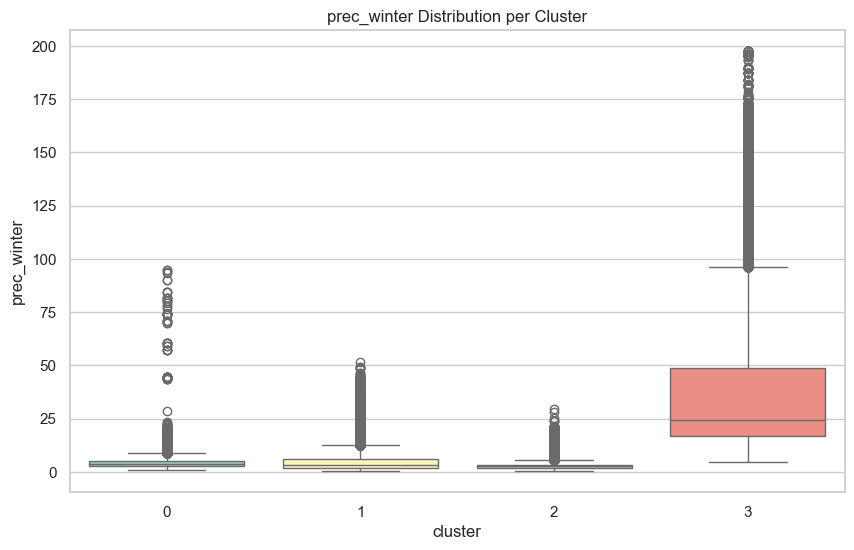

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1402903861.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_all, palette='Set3')


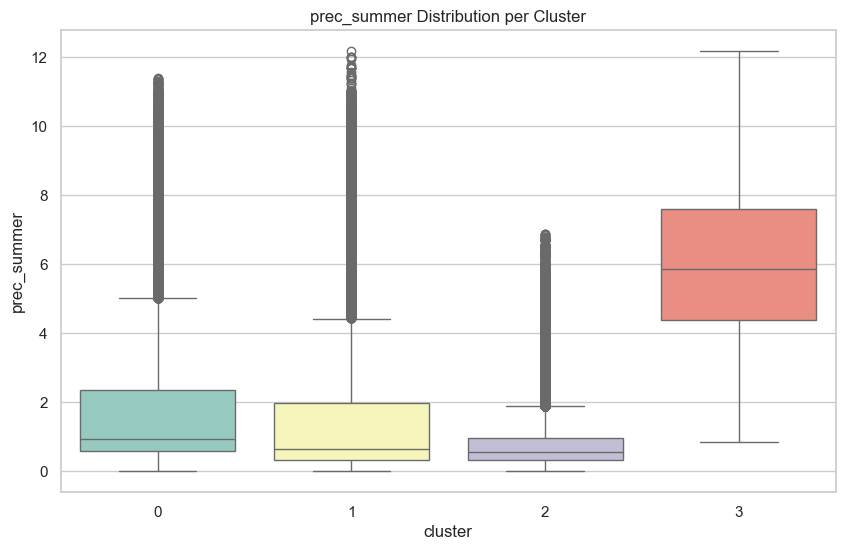

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1402903861.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_all, palette='Set3')


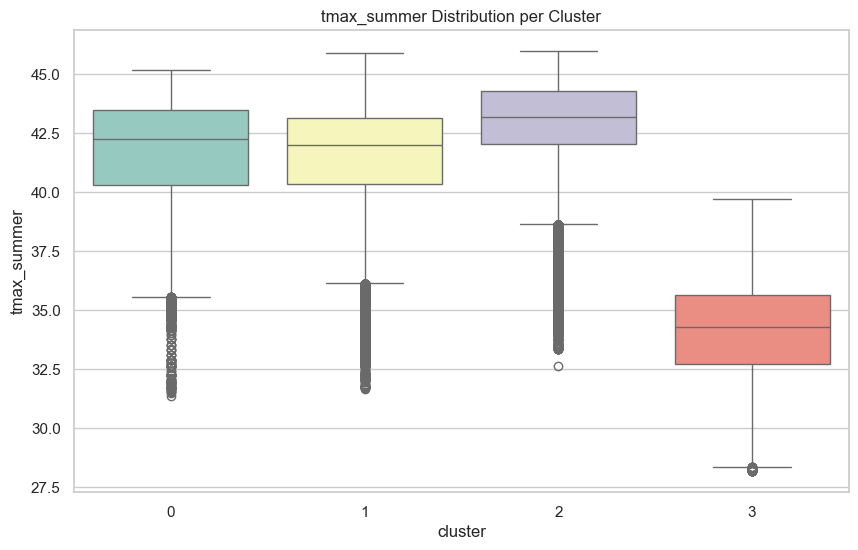

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1402903861.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_all, palette='Set3')


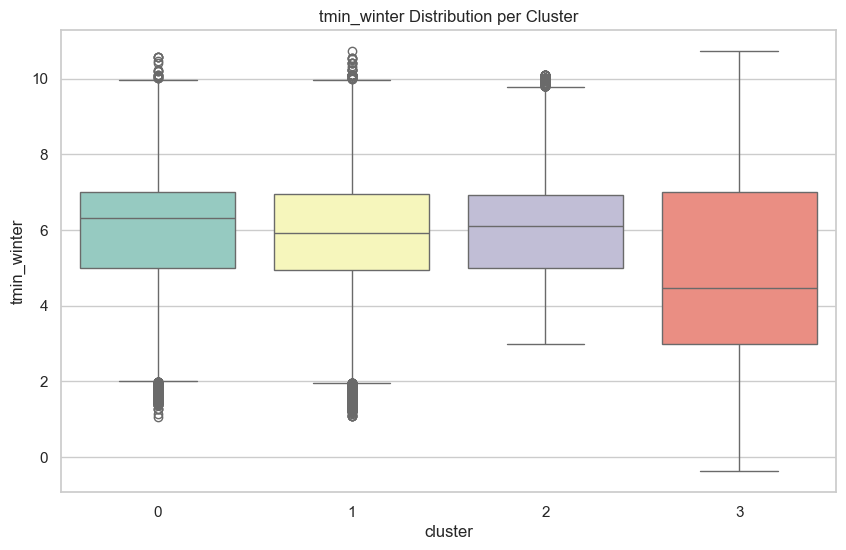

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1402903861.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_all, palette='Set3')


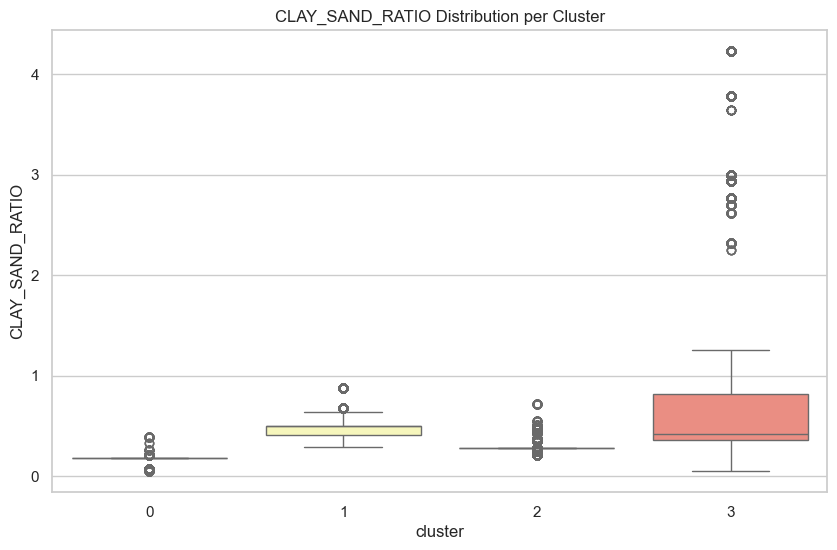

In [35]:
key_features = ['prec_winter', 'prec_summer', 'tmax_summer', 'tmin_winter', 'CLAY_SAND_RATIO']
# ------------------------------
# 6. Boxplots of key features per cluster
# ------------------------------
for feature in key_features:
    plt.figure()
    sns.boxplot(x='cluster', y=feature, data=df_all, palette='Set3')
    plt.title(f"{feature} Distribution per Cluster")
    plt.show()

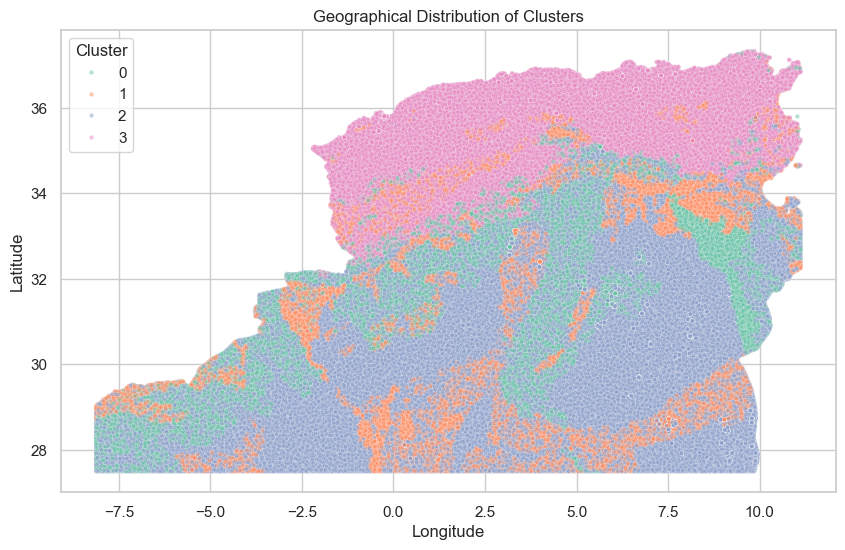

In [36]:
# ------------------------------
# 7. Geographic plot: clusters
# ------------------------------
if 'lat' in df_all.columns and 'lon' in df_all.columns:
    plt.figure()
    sns.scatterplot(
        x='lon', y='lat',
        hue='cluster',
        data=df_all,
        palette='Set2',
        s=10,
        alpha=0.5
    )
    plt.title("Geographical Distribution of Clusters")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend(title='Cluster')
    plt.show()


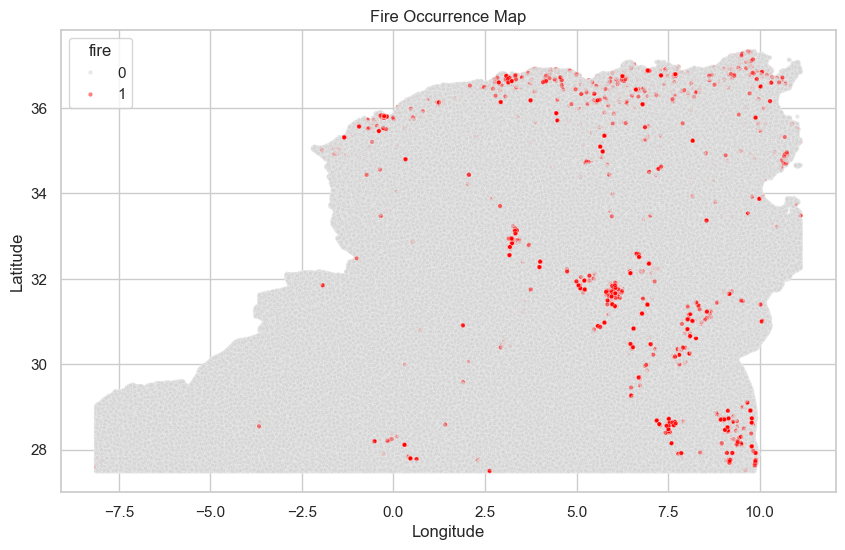

In [37]:
# ------------------------------
# 8. Geographic plot: fire occurrence
# ------------------------------
plt.figure()
sns.scatterplot(
    x='lon', y='lat',
    hue='fire',
    data=df_all,
    palette={0:'lightgray', 1:'red'},
    s=10,
    alpha=0.5
)
plt.title("Fire Occurrence Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

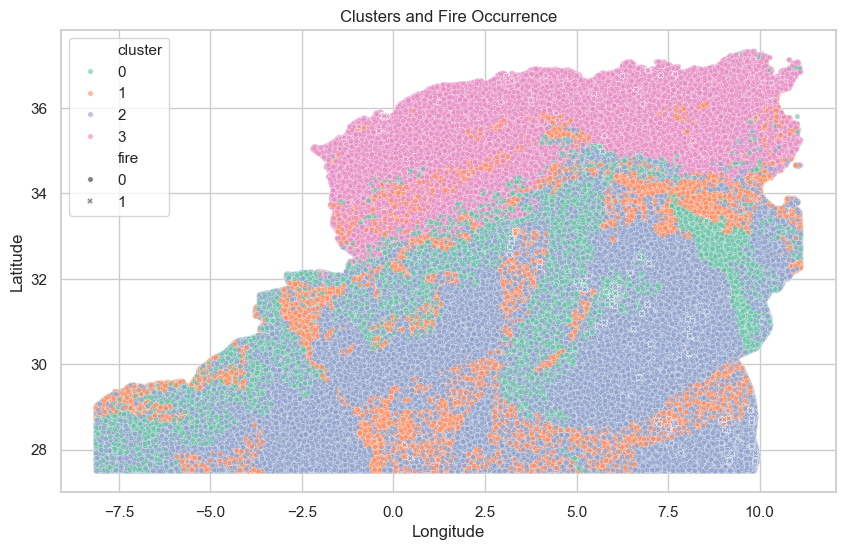

In [40]:
# ------------------------------
# 9. Geographic plot: clusters + fire markers
# ------------------------------
plt.figure()
sns.scatterplot(
    x='lon', y='lat',
    hue='cluster',
    style='fire',
    data=df_all,
    palette='Set2',
    s=15,
    alpha=0.6
)
plt.title("Clusters and Fire Occurrence")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


K-Means from scratch

In [41]:
class ScratchKmeans:
    """
    K-Means clustering algorithm implementation.

    Parameters:
        K (int): Number of clusters

    Attributes:
        K (int): Number of clusters
        centroids (numpy.ndarray): Array containing the centroids of each cluster

    Methods:
        __init__(self, K): Initializes the Kmeans instance with the specified number of clusters.
        initialize_centroids(self, X): Initializes the centroids for each cluster by selecting K random points from the dataset.
        assign_points_centroids(self, X): Assigns each point in the dataset to the nearest centroid.
        compute_mean(self, X, points): Computes the mean of the points assigned to each centroid.
        fit(self, X, iterations=10): Clusters the dataset using the K-Means algorithm.
    """
    
    def __init__(self, K):
        assert K > 0, "K should be a positive integer."
        self.K = K
        
    def initialize_centroids(self, X):
        assert X.shape[0] >= self.K, "Number of data points should be greater than or equal to K."
        
        randomized_X = np.random.permutation(X.shape[0]) 
        centroid_idx = randomized_X[:self.K] # get the indices for the centroids
        self.centroids = X[centroid_idx] # assign the centroids to the selected points
        
    def assign_points_centroids(self, X):
        """
        Assign each point in the dataset to the nearest centroid.
        
        Parameters:
        X (numpy.ndarray): dataset to cluster
        
        Returns:
        numpy.ndarray: array containing the index of the centroid for each point
        """
        X = np.expand_dims(X, axis=1) # expand dimensions to match shape of centroids
        distance = np.linalg.norm((X - self.centroids), axis=-1) # calculate Euclidean distance between each point and each centroid
        points = np.argmin(distance, axis=1) # assign each point to the closest centroid
        assert len(points) == X.shape[0], "Number of assigned points should equal the number of data points."
        return points
    
    def compute_mean(self, X, points):
        """
        Compute the mean of the points assigned to each centroid.
        
        Parameters:
        X (numpy.ndarray): dataset to cluster
        points (numpy.ndarray): array containing the index of the centroid for each point
        
        Returns:
        numpy.ndarray: array containing the new centroids for each cluster
        """
        centroids = np.zeros((self.K, X.shape[1])) # initialize array to store centroids
        for i in range(self.K):
            centroid_mean = X[points == i].mean(axis=0) # calculate mean of the points assigned to the current centroid
            centroids[i] = centroid_mean # assign the new centroid to the mean of its points
        return centroids
    
    def fit(self, X, iterations=10):
        """
        Cluster the dataset using the K-Means algorithm.
        
        Parameters:
        X (numpy.ndarray): dataset to cluster
        iterations (int): number of iterations to perform (default=10)
        
        Returns:
        numpy.ndarray: array containing the final centroids for each cluster
        numpy.ndarray: array containing the index of the centroid for each point
        """
        self.initialize_centroids(X) # initialize the centroids
        for i in range(iterations):
            points = self.assign_points_centroids(X) # assign each point to the nearest centroid
            self.centroids = self.compute_mean(X, points) # compute the new centroids based on the mean of their points
            
            # Assertions for debugging and validation
            assert len(self.centroids) == self.K, "Number of centroids should equal K."
            assert X.shape[1] == self.centroids.shape[1], "Dimensionality of centroids should match input data."
            assert max(points) < self.K, "Cluster index should be less than K."
            assert min(points) >= 0, "Cluster index should be non-negative."
            
        return self.centroids, points


In [43]:
K = 4

# Initialize and fit custom KMeans
kmeans_custom = ScratchKmeans(K)
centroids_custom, labels_custom = kmeans_custom.fit(X_np, iterations=50)

# Assign cluster labels to dataframe
df_all['cluster_custom'] = labels_custom

# Cluster sizes
print("Custom KMeans cluster sizes:")
print(df_all['cluster_custom'].value_counts())

# Fire probability per cluster
print("Custom KMeans fire proportion per cluster:")
print(df_all.groupby('cluster_custom')['fire'].mean())


Custom KMeans cluster sizes:
cluster_custom
0    256445
1     80103
2     60250
3     32161
Name: count, dtype: int64
Custom KMeans fire proportion per cluster:
cluster_custom
0    0.226204
1    0.145700
2    0.188133
3    0.248033
Name: fire, dtype: float64


comparison

In [44]:
df_all.rename(columns={'cluster': 'cluster_sklearn'}, inplace=True)


C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1199437010.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster_custom', data=df_all, palette='Set2')


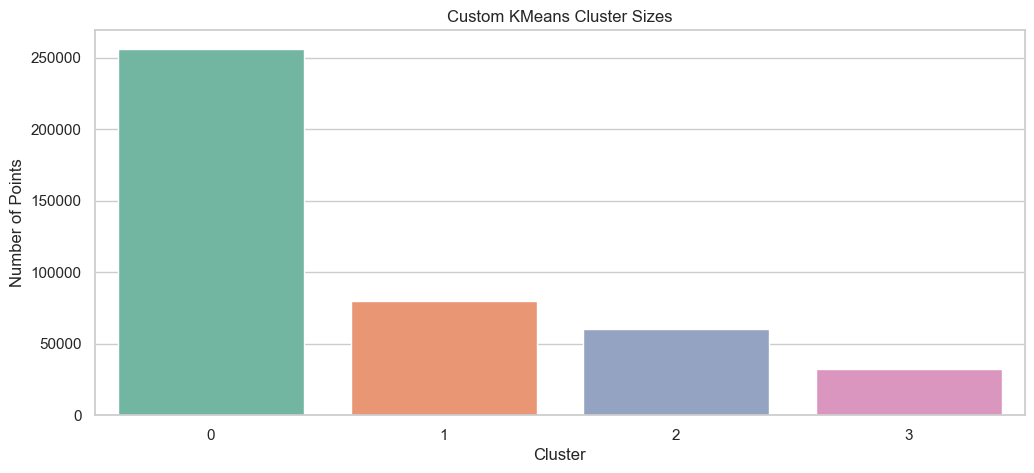

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1199437010.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster_sklearn', data=df_all, palette='Set2')


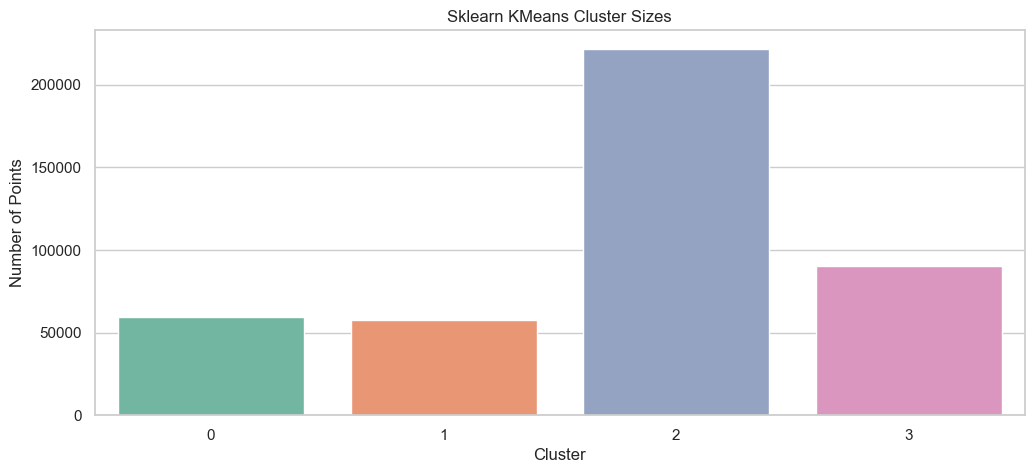

In [45]:

plt.figure(figsize=(12,5))
sns.countplot(x='cluster_custom', data=df_all, palette='Set2')
plt.title("Custom KMeans Cluster Sizes")
plt.xlabel("Cluster")
plt.ylabel("Number of Points")
plt.show()

plt.figure(figsize=(12,5))
sns.countplot(x='cluster_sklearn', data=df_all, palette='Set2')
plt.title("Sklearn KMeans Cluster Sizes")
plt.xlabel("Cluster")
plt.ylabel("Number of Points")
plt.show()



C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1042538298.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fire_custom.index, y=fire_custom.values, ax=axes[0], palette='Reds')
C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1042538298.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fire_sklearn.index, y=fire_sklearn.values, ax=axes[1], palette='Reds')


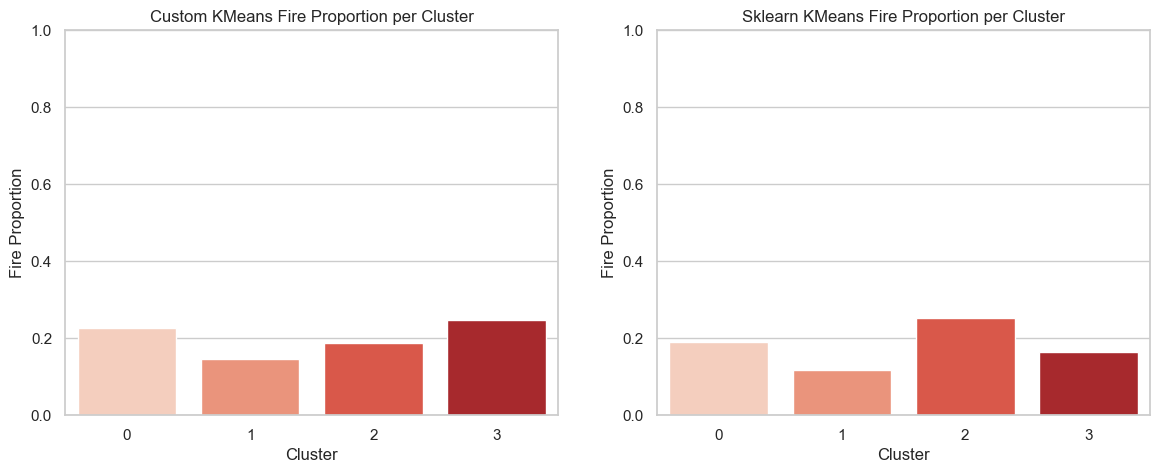

In [46]:
fire_custom = df_all.groupby('cluster_custom')['fire'].mean()
fire_sklearn = df_all.groupby('cluster_sklearn')['fire'].mean()

fig, axes = plt.subplots(1,2, figsize=(14,5))
sns.barplot(x=fire_custom.index, y=fire_custom.values, ax=axes[0], palette='Reds')
axes[0].set_title("Custom KMeans Fire Proportion per Cluster")
axes[0].set_ylim(0,1)
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Fire Proportion")

sns.barplot(x=fire_sklearn.index, y=fire_sklearn.values, ax=axes[1], palette='Reds')
axes[1].set_title("Sklearn KMeans Fire Proportion per Cluster")
axes[1].set_ylim(0,1)
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Fire Proportion")

plt.show()


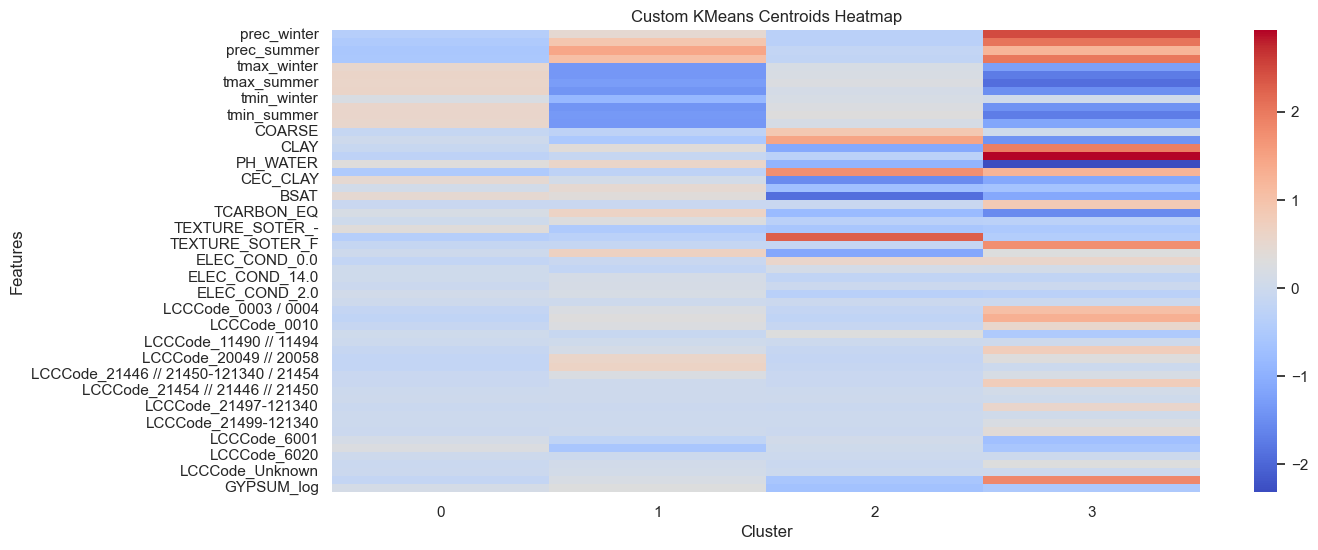

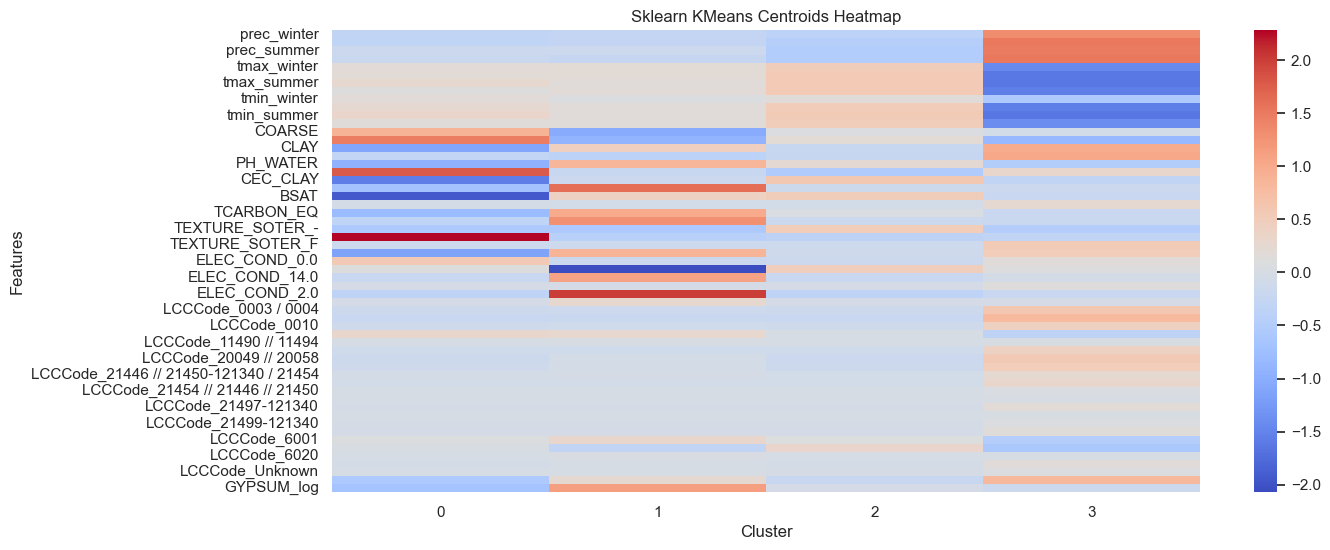

In [48]:
# Custom centroids
centroids_custom_df = pd.DataFrame(centroids_custom, columns=numeric_cols)
centroids_custom_df['cluster'] = range(K)
centroids_custom_df.set_index('cluster', inplace=True)

# Sklearn centroids
centroids_sklearn_df = pd.DataFrame(kmeans.cluster_centers_, columns=numeric_cols)
centroids_sklearn_df['cluster'] = range(K)
centroids_sklearn_df.set_index('cluster', inplace=True)

# Plot heatmaps
plt.figure(figsize=(14,6))
sns.heatmap(centroids_custom_df.T, cmap='coolwarm', annot=False)
plt.title("Custom KMeans Centroids Heatmap")
plt.xlabel("Cluster")
plt.ylabel("Features")
plt.show()

plt.figure(figsize=(14,6))
sns.heatmap(centroids_sklearn_df.T, cmap='coolwarm', annot=False)
plt.title("Sklearn KMeans Centroids Heatmap")
plt.xlabel("Cluster")
plt.ylabel("Features")
plt.show()


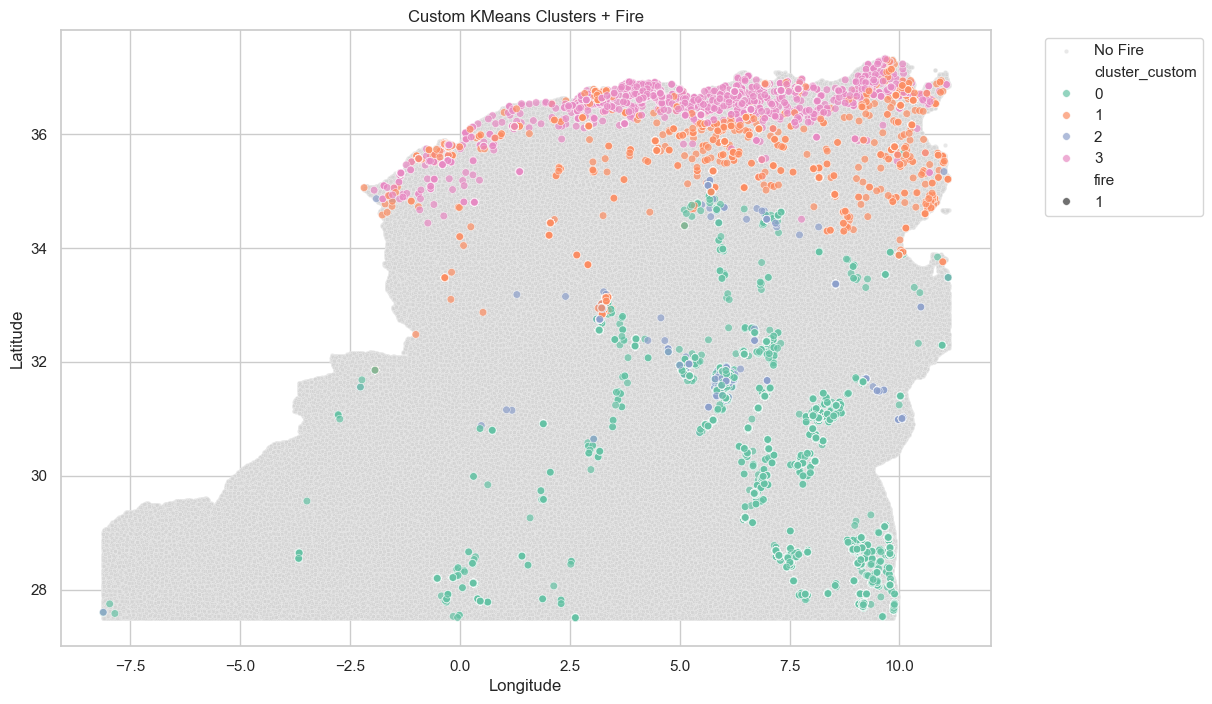

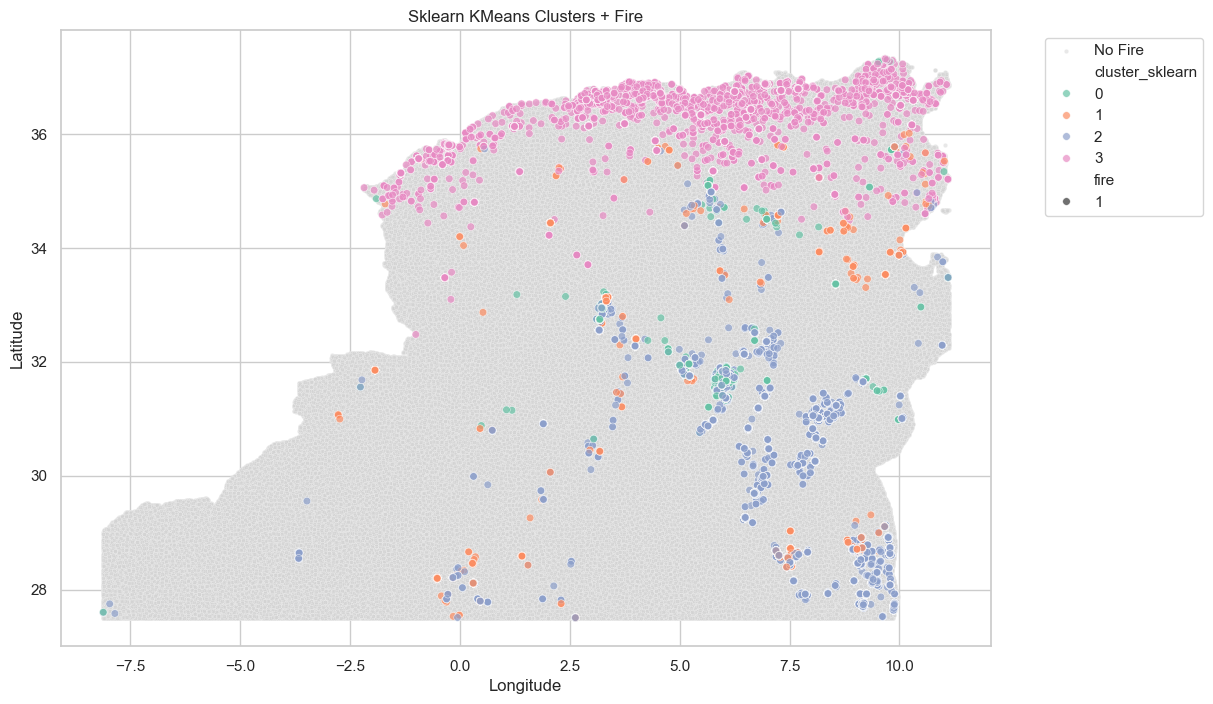

In [49]:
# Function to plot clusters + fire
def plot_geo_clusters(df, cluster_col, title):
    plt.figure(figsize=(12,8))
    
    # Non-fire points
    sns.scatterplot(
        x='lon', y='lat',
        data=df[df['fire']==0],
        color='lightgray',
        s=10,
        alpha=0.5,
        label='No Fire'
    )
    
    # Fire points
    sns.scatterplot(
        x='lon', y='lat',
        hue=cluster_col,
        style='fire',
        data=df[df['fire']==1],
        palette='Set2',
        s=30,
        alpha=0.7,
        legend='full'
    )
    
    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

# Custom
plot_geo_clusters(df_all, 'cluster_custom', "Custom KMeans Clusters + Fire")

# Sklearn
plot_geo_clusters(df_all, 'cluster_sklearn', "Sklearn KMeans Clusters + Fire")


C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1830925318.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_custom', y=feature, data=df_all, palette='Set3')


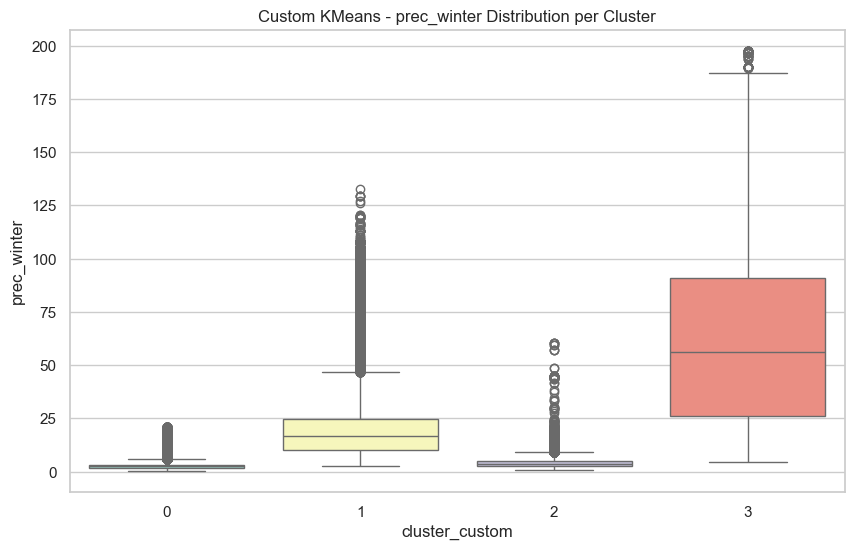

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1830925318.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_custom', y=feature, data=df_all, palette='Set3')


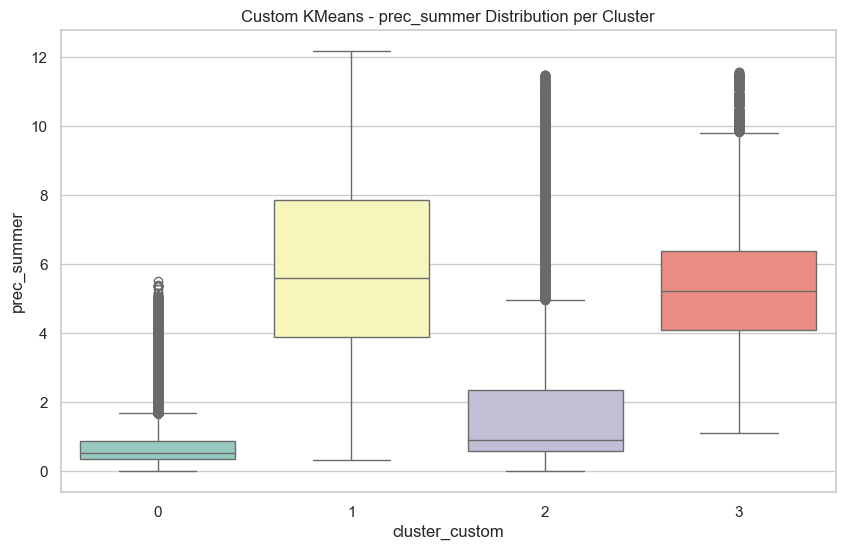

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1830925318.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_custom', y=feature, data=df_all, palette='Set3')


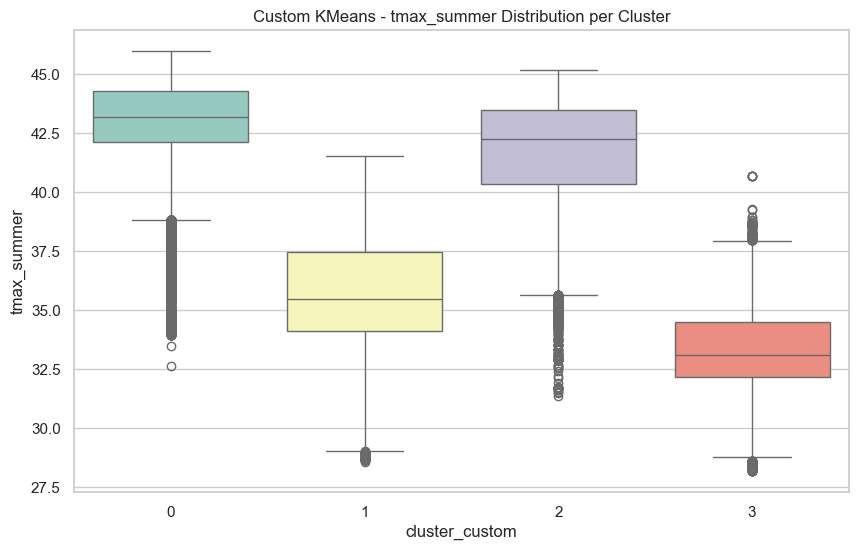

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1830925318.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_custom', y=feature, data=df_all, palette='Set3')


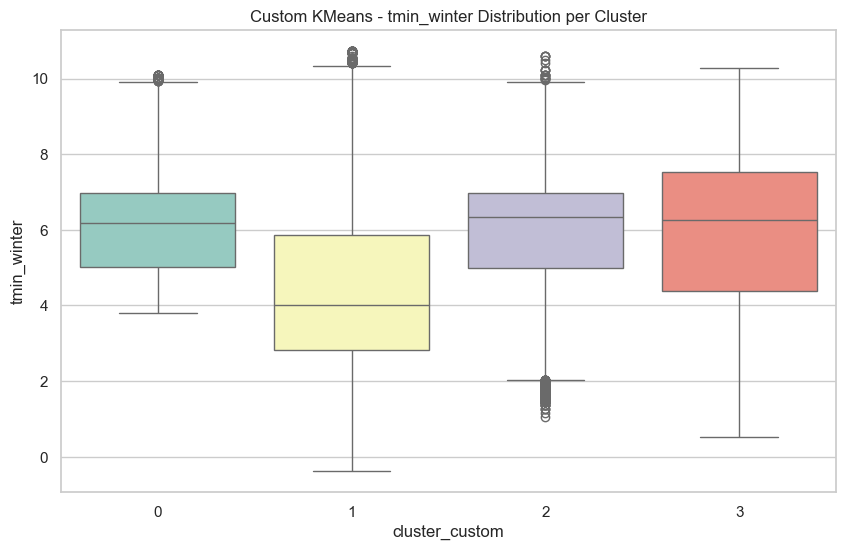

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1830925318.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_custom', y=feature, data=df_all, palette='Set3')


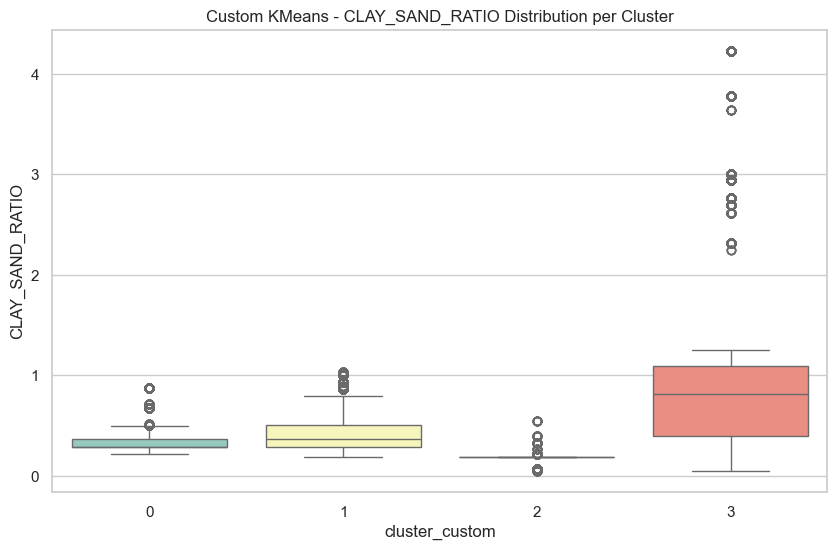

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1830925318.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_sklearn', y=feature, data=df_all, palette='Set3')


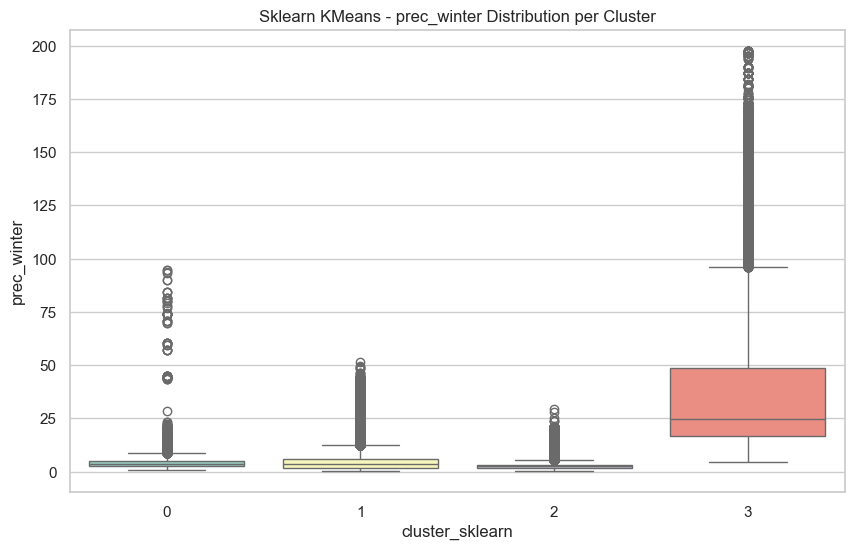

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1830925318.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_sklearn', y=feature, data=df_all, palette='Set3')


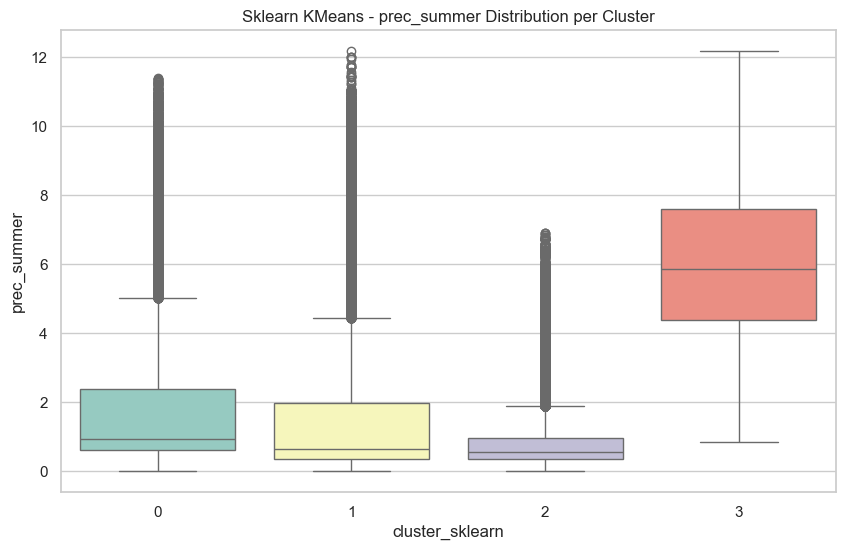

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1830925318.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_sklearn', y=feature, data=df_all, palette='Set3')


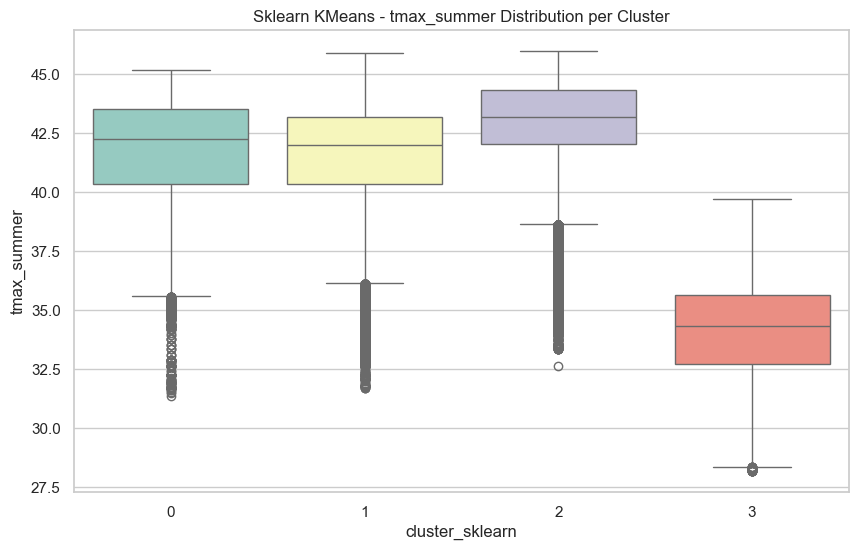

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1830925318.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_sklearn', y=feature, data=df_all, palette='Set3')


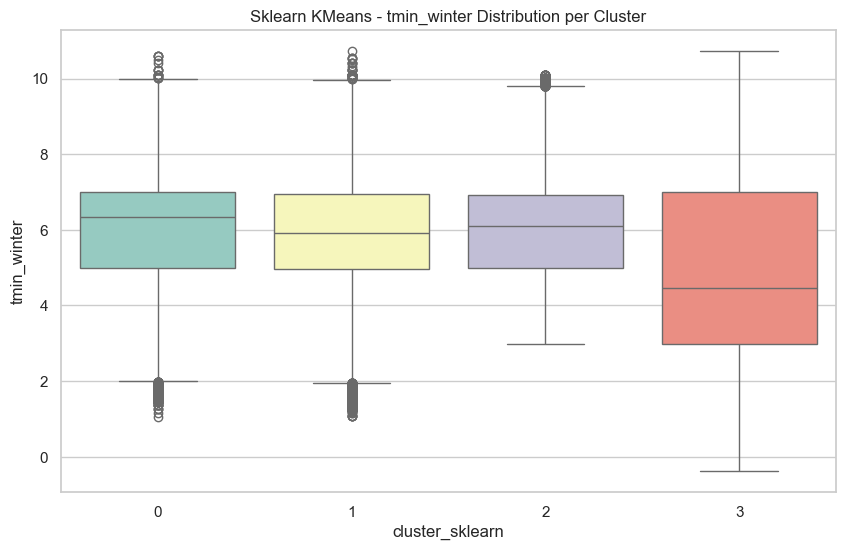

C:\Users\dell\AppData\Local\Temp\ipykernel_16736\1830925318.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_sklearn', y=feature, data=df_all, palette='Set3')


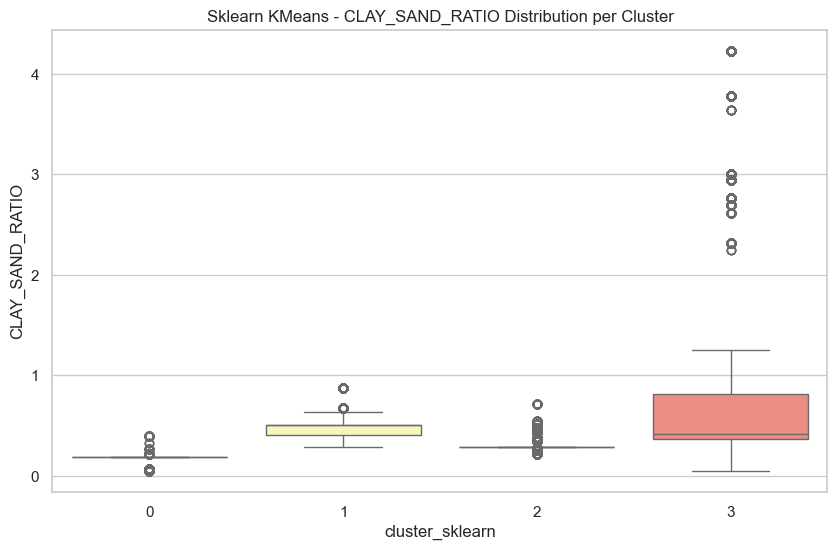

In [50]:
key_features = ['prec_winter', 'prec_summer', 'tmax_summer', 'tmin_winter', 'CLAY_SAND_RATIO']

# Custom KMeans
for feature in key_features:
    plt.figure()
    sns.boxplot(x='cluster_custom', y=feature, data=df_all, palette='Set3')
    plt.title(f"Custom KMeans - {feature} Distribution per Cluster")
    plt.show()

# Sklearn KMeans
for feature in key_features:
    plt.figure()
    sns.boxplot(x='cluster_sklearn', y=feature, data=df_all, palette='Set3')
    plt.title(f"Sklearn KMeans - {feature} Distribution per Cluster")
    plt.show()


## dbscan

In [51]:
from sklearn.decomposition import PCA

n_components = 15  # choose 10–15 components to keep most variance
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_np)
print("Shape before PCA:", X_np.shape)
print("Shape after PCA:", X_pca.shape)
print("Variance explained:", pca.explained_variance_ratio_.sum())

Shape before PCA: (428959, 57)
Shape after PCA: (428959, 15)
Variance explained: 0.6779678779994008


```The dataset contains 57 numeric features, many of which are correlated and high-dimensional. DBSCAN relies on distance between points to identify dense clusters, but in high dimensions, distances become less meaningful — this is known as the curse of dimensionality. To address this, Principal Component Analysis (PCA) is applied before DBSCAN to reduce the number of features while retaining most of the variance in the data. By projecting the data onto the first few principal components (e.g., 10–15), we preserve the main patterns and relationships among features, making the distance calculations more reliable for DBSCAN. This allows the algorithm to detect meaningful dense clusters and separate noise points effectively, without being overwhelmed by redundant or irrelevant dimensions.```

now tuning dbscan

In [52]:
# eps: distance threshold
eps_candidates = np.arange(1.5, 4.0, 0.5)  # adjust depending on your k-distance plot

# min_samples: minimum points to form a dense cluster
min_samples_candidates = [30, 50, 100]  # small → many clusters, large → only dense clusters

# metric: distance metric
metrics = ['euclidean', 'manhattan']  # usually euclidean is fine


In [ ]:
from sklearn.cluster import DBSCAN
import pandas as pd

results = []

for eps in eps_candidates:
    for min_s in min_samples_candidates:
        for metric in metrics:
            dbscan = DBSCAN(eps=eps, min_samples=min_s, metric=metric, n_jobs=-1)
            labels = dbscan.fit_predict(X_pca)
            
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)
            fire_mean = df_all.assign(cluster_db=labels).groupby('cluster_db')['fire'].mean().mean()
            
            results.append({
                'eps': eps,
                'min_samples': min_s,
                'metric': metric,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'avg_fire_ratio': fire_mean
            })

# Convert to DataFrame for easy analysis
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='n_clusters', ascending=False)  # or any other metric
print(results_df)
